# Import Packages

In [1]:
# region Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
from joblib import Parallel, delayed    # Necessary for parallelization
import networkx as nx                   # Only for classification tree
from copy import deepcopy
from itertools import product
from matplotlib import colormaps
import os
from scipy.optimize import minimize
from scipy.stats import (
    chi2,
    norm)

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    accuracy_score,
    confusion_matrix
)
# endregion

In [2]:
os.chdir(r"C:\Users\gianl\PycharmProjects\pythonProject3")

# Functions

In [1]:
# region Global Variables
def OPTIMIZATION_BOUNDS(n_risk):
    return [(0.01, 1), (0.5, 10), (-np.inf, np.inf), (0, np.inf)] + [(-np.inf, np.inf)] * n_risk
# n ∈ [0.01, 1], α/β ∈ [0.5, 10], beta_0 ∈ ℝ, beta_eud > 0, beta_risk ∈ ℝ ∀ risk factor

def GRID_OPTIMIZATION_BF(p, n_risk):
    bounds = OPTIMIZATION_BOUNDS(n_risk)

    n_min, n_max = bounds[0]
    ab_min, ab_max = bounds[1]
    beta0_min, beta0_max = bounds[2]

    step_n = 0.05
    step_ab = 0.5

    n_steps = int(round(n_max / step_n))
    ab_steps = int(round(ab_max / step_ab))

    n_vals = np.array([n_min] + [step_n * i for i in range(1, n_steps + 1)])
    a_b_vals = np.array([step_ab * i for i in range(1, ab_steps + 1)])

    logit_p = np.log(p / (1 - p))
    beta_0_vals = np.linspace(
        max(0.15 * logit_p, beta0_min),
        min(4.0 * logit_p, beta0_max),
        15
    )

    beta_EUD_vals = [0.01 * i for i in range(8)]
    beta_risk_vals = [[0] for _ in range(n_risk)]

    return {
        "n": n_vals,
        "a_b": a_b_vals,
        "beta_0": beta_0_vals,
        "beta_EUD": beta_EUD_vals,
        "beta_risk": beta_risk_vals
    }

def GRID_CHECK_CONVERGENCE(p, n_risk):
    bounds = OPTIMIZATION_BOUNDS(n_risk)

    n_min, n_max = bounds[0]
    ab_min, ab_max = bounds[1]

    step_n = 0.05
    step_ab = 0.5

    n_steps = int(round(n_max / step_n))
    ab_steps = int(round(ab_max / step_ab))

    n_vals = np.array([n_min] + [step_n * i for i in range(1, n_steps + 1)])
    a_b_vals = np.array([ab_min] + [step_ab * i for i in range(2, ab_steps + 1)])

    beta_0_vals = np.linspace(0, 10 * np.log(p / (1 - p)), 20)

    alpha_eud = np.linspace(0, 1, 20) ** 2
    beta_EUD_vals = np.log(1.0 + (1.5 - 1.0) * alpha_eud)

    beta_risk_vals = []
    for _ in range(n_risk):
        alpha_r = np.linspace(0, 1, 15) ** 2
        beta_risk_vals.append(np.log(0.3 + (3.0 - 0.3) * alpha_r))

    return {
        "n": n_vals,
        "a_b": a_b_vals,
        "beta_0": beta_0_vals,
        "beta_EUD": beta_EUD_vals,
        "beta_risk": beta_risk_vals
    }

OPTIMIZATION_ALGORITHM = 'L-BFGS-B'
INITIAL_GUESSES_BRUTE_FORCE = 5
# REFINEMENT_OPTIMIZATION_OPTIONS = {'maxiter': 1000, 'ftol': 1e-6, 'gtol': 1e-8}
REFINEMENT_OPTIMIZATION_OPTIONS = None 
# Default options: {'maxiter': 15000, 'ftol': 2.220446049250313e-09, 'gtol': 1e-05}

# maxiter: Maximum number of algorithm iterations.
# ftol: The iteration stops when (f^k - f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol
# gtol: The iteration will stop when max{|proj g_i | i = 1, ..., n} <= gtol where proj g_i is the i-th component of the projected gradient.

# endregion

# region Create data
def create_data(outcome, cumulative_dsh, n_fractions, risk_factors=None, impute_risk_factors=True):
    """
    Prepares and aligns clinical and dosimetric data for NTCP modeling.

    This function aligns outcome labels, cumulative dose-volume histograms,
    fractionation data, and optional clinical risk factors using patient IDs
    as the unique key. The cumulative DVH is converted into a Differential
    Dose-Volume Histogram (DSH).

    Missing values in risk factors can either be imputed with zeros or cause
    the corresponding patients to be removed from all datasets.

    Parameters
    ----------
    outcome : pandas.DataFrame
        DataFrame containing patient outcomes. The first column must contain
        patient IDs, and the second column the binary outcome (0/1).

    cumulative_dsh : pandas.DataFrame
        DataFrame containing cumulative dose-volume histograms. The first column
        must contain patient IDs, and the remaining columns cumulative DVH values.

    n_fractions : int, float, or pandas.DataFrame
        Number of fractions per patient. If a scalar is provided, the same value
        is assigned to all patients. If a DataFrame is provided, the first column
        must be patient IDs and the second the number of fractions.

    risk_factors : pandas.DataFrame, optional
        DataFrame containing additional clinical risk factors. The first column
        must contain patient IDs. Remaining columns are treated as covariates.

    impute_risk_factors : bool, default=True
        If True, missing values in risk factors are imputed with 0.
        If False, patients with missing risk factors are removed and all other
        data are realigned accordingly.

    Returns
    -------
    dict
        Dictionary containing:
            - "outcome": numpy array of binary outcomes
            - "DSH": numpy array of Differential Dose-Volume Histograms
            - "n_fractions": numpy array of fraction numbers
            - "original_bins": numpy array of DSH bin starting points
            - "risk_factors": pandas DataFrame of aligned risk factors
            - "id": numpy array of patient IDs
    """
    # --- Standardize column names and copy inputs ---
    outcome = outcome.copy().rename(columns={outcome.columns[0]: "id"})
    cumulative_dsh = cumulative_dsh.copy().rename(columns={cumulative_dsh.columns[0]: "id"})

    # --- Standardize n_fractions (rename columns and create data frame if a single value is given) ---
    if isinstance(n_fractions, (int, float)):
        n_fractions = pd.DataFrame({
            "id": outcome["id"],
            "n_fractions": n_fractions
        })
    else:
        n_fractions = n_fractions.copy()
        n_fractions = n_fractions.rename(columns={
            n_fractions.columns[0]: "id",
            n_fractions.columns[1]: "n_fractions"
        })

    # --- Standardize risk factors (rename columns) ---
    if risk_factors is not None and risk_factors.shape[1] > 0:
        risk_factors = risk_factors.copy().rename(columns={risk_factors.columns[0]: "id"})
        if any(c is None or c == "" for c in risk_factors.columns[1:]):
            risk_factors.columns = ["id"] + [
                f"risk_{i+1}" for i in range(risk_factors.shape[1] - 1)
            ]

    # --- Build master table defining valid IDs and their order ---
    data = outcome.merge(n_fractions, on="id", how="inner")

    if risk_factors is not None and risk_factors.shape[1] > 1:
        data = data.merge(risk_factors, on="id", how="left")
        rf_cols = risk_factors.columns[1:]

        if impute_risk_factors:
            data[rf_cols] = data[rf_cols].fillna(0)
        else:
            data = data.dropna(subset=rf_cols)

    # --- Align cumulative DSH to the final set and order of IDs ---
    valid_ids = data["id"]
    cumulative_dsh = (
        cumulative_dsh[cumulative_dsh["id"].isin(valid_ids)]
        .set_index("id")
        .loc[valid_ids]
        .reset_index()
    )

    # --- Compute Differential DSH ---
    DSH, original_bins = compute_DSH(cumulative_dsh)
    DSH = DSH.iloc[:, 1:]

    # --- Extract arrays for modeling ---
    outcome_array = data.iloc[:, 1].to_numpy()
    n_frac = data["n_fractions"].to_numpy()
    id_array = data["id"].to_numpy()

    if risk_factors is not None and risk_factors.shape[1] > 1:
        risk_factors_df = data[rf_cols].reset_index(drop=True)
    else:
        risk_factors_df = pd.DataFrame(index=data.index)

    return {
        "outcome": outcome_array,
        "DSH": DSH.to_numpy(),
        "n_fractions": n_frac,
        "original_bins": original_bins,
        "risk_factors": risk_factors_df,
        "id": id_array
    }

def compute_DSH(cumulative_dsh):
    """
    Computes the Differential Dose-Volume Histogram (DSH) from a cumulative dose-volume histogram.

    This function converts a cumulative dose distribution into a differential histogram by taking 
    the difference between consecutive dose bins. It also normalizes values if they are in percentage 
    format (0-100) and returns the corresponding original bin edges.

    Parameters
    ----------
    cumulative_dsh : pandas.DataFrame
        DataFrame containing cumulative dose distributions. The first column should be patient IDs,
        subsequent columns contain cumulative dose-volume values for each dose bin.
        IMPORTANT: Each column name must represent the corresponding dose level.
    Returns
    -------
    DSH : pandas.DataFrame
        DataFrame containing the differential dose-volume histogram. The first column is patient IDs,
        and the remaining columns correspond to differential dose bins in the format "[bin_start, bin_end)".

    original_bins : numpy.ndarray
        Array of the starting values of each dose bin, extracted from the column names of the DSH.
    """
    cumulative_dsh = cumulative_dsh.copy()
    cumulative_dsh.fillna(0, inplace=True)
    if cumulative_dsh.iloc[:, 1:].max().max() > 1:
        cols = cumulative_dsh.columns[1:]
        cumulative_dsh[cols] = cumulative_dsh[cols].to_numpy(dtype=float) / 100.0
    DSH = cumulative_dsh.iloc[:, [0]]
    diff_cols = {}
    dsh_cols = []
    for i in range(1, len(cumulative_dsh.columns) - 1):
        col1 = cumulative_dsh.columns[i]
        col2 = cumulative_dsh.columns[i + 1]
        new_col_name = f"[{col1}, {col2})"
        dsh_cols.append(new_col_name)
        diff_cols[new_col_name] = cumulative_dsh[col1] - cumulative_dsh[col2]
    DSH = pd.concat([DSH, pd.DataFrame(diff_cols)], axis=1)
    last_col = cumulative_dsh.columns[-1]
    DSH[last_col] = cumulative_dsh[last_col]
    dsh_cols.append(last_col)
    original_bins = [float(str(col).strip('[]()').split(',')[0]) for col in dsh_cols]
    return DSH, np.array(original_bins)

def data_to_dataframe(data):
    """
    Converts the output of create_data into a single pandas DataFrame.

    The resulting DataFrame contains one row per patient and includes:
    - patient identifier
    - outcome label
    - number of fractions
    - clinical risk factors (if present)
    - differential DSH values

    DSH columns are named using the corresponding values in
    data["original_bins"], ensuring a direct mapping between dose bins
    and histogram values.

    Parameters
    ----------
    data : dict
        Dictionary returned by create_data, with keys:
        "id", "outcome", "n_fractions", "DSH",
        "original_bins", and "risk_factors".

    Returns
    -------
    pandas.DataFrame
        DataFrame with all patient-level information and DSH bins
        as separate columns.
    """
    df = pd.DataFrame({
        "id": data["id"],
        "outcome": data["outcome"],
        "n_fractions": data["n_fractions"]
    })

    if data["risk_factors"] is not None and data["risk_factors"].shape[1] > 0:
        rf = data["risk_factors"].reset_index(drop=True)
        df = pd.concat([df, rf], axis=1)

    dsh_cols = [str(b) for b in data["original_bins"]]
    dsh_df = pd.DataFrame(data["DSH"], columns=dsh_cols)

    df = pd.concat([df, dsh_df], axis=1)

    return df
# endregion

# region Utility Functions
def predict_logistic(data, params):
    """
    Computes logistic model predictions by applying a sigmoid to the computed scores.

    Parameters
    ----------
    data : dict
        Container holding the dose-related inputs and risk factors required by the model.

    params : array-like
        Model parameters in the following order:
        n, a_b, b_0, b_eud, followed by optional risk-factor coefficients.

    Returns
    -------
    numpy.ndarray
        Predicted probabilities from the logistic model.
    """
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()

    n = params[0]
    a_b = params[1]
    b_0 = params[2]
    b_eud = params[3]
    b_risk = params[4:] if risk_matrix.shape[1] > 0 else []

    corrected_doses = EQD2(original_bins, n_fractions, a_b)       # EQD2-corrected dose bins
    EUDs = compute_EUDs(surfaces_matrix, corrected_doses, n)      # Compute EUD values
    scores = b_0 + b_eud * EUDs                                   # Base logistic score
    if risk_matrix is not None and len(b_risk) > 0:
        scores += np.dot(risk_matrix, np.array(b_risk))           # Add risk-factor contribution
    return sigmoid(scores)                                         # Convert scores to probabilities

def sigmoid(x): 
    # Implements the sigmoid function
    x = np.clip(x, -500, 500)
    return 1 / (1 + np.exp(-x))

def logistic_to_lyman(params):
    # Implements the tranformation from logistic parameters (input: params) to lyman parameters
    n = params[0]
    a_b = params[1]
    b0 = params[2]
    b_eud = params[3]
    b_risks = params[4:]

    td50 = - b0/b_eud
    m = -1/(b0 + sum(b_risks))
    dmfs = [1 + b/b0 for b in b_risks]

    return np.array([n, a_b, td50, m] + dmfs)
# endregion

# region Optimization Functions
def fit_model(data, N_jk=1, p_jk=1, verbose=1):
    """
    Fits the logistic NTCP model, optionally using Jack-Knife resampling. The resampling is stratified based on data['outcome'], 
    keeping the same proportion of events and non-events.

    Parameters
    ----------
    data : dict
        Input data used for model fitting.

    N_jk : int, optional
        Number of Jack-Knife iterations. If >1, Jack-Knife resampling is applied.

    p_jk : float, optional
        Fraction of the dataset sampled in each Jack-Knife iteration.

    verbose : int, optional
        Controls the verbosity of printed output.

    Returns
    -------
    dict
        If N_jk > 1:
            DataFrame containing the N_jk final solutions after refinement (N_jk rows)
        Else:
            {
                "best_refined_results": DataFrame,
                "all_refined_results": DataFrame,
                "best_bf_results": DataFrame
            }  
            - best_refined_results: the final solution after refinement (1 row)  
            - all_refined_results: all initial guesses after refinement  
            - best_bf_results: selected initial guesses
    """
    if verbose > 0:
        if N_jk > 1:
            print(f"\nStart Jack-Knife Fitting ({N_jk:.0f} iterations, {p_jk*100:.0f}% sampling)...")
        else:
            print(f"\nStart Fitting (No Jack-Knife)...")

    risk_factors_names = list(data["risk_factors"].columns)
    param_names = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in risk_factors_names] + ["-log(L)"]

    if N_jk > 1: # Jack-Knife fitting: each core is assigned a batch of iterations, and each optimization is performed without parallelization
        best_refined_results = Parallel(n_jobs=-1, verbose=verbose)(
            delayed(_jackknife_single)(
                seed, data, p_jk, parallelize=False, return_only_best=True
            ) for seed in range(N_jk)
        ) # calls _jackknife_single, that performs a single Jack-Knife optimization

        best_refined_results = np.array(best_refined_results)
        df_results = pd.DataFrame(best_refined_results, columns=param_names).reset_index(drop=True)
        return df_results
    else: 
        # No Jack-Knife: N_jk = 1 and p_jk = 1 (no resampling), and the optimization is performed parallelizing both grid search and refining steps
        best_refined_results, all_refined_results, best_bf_results = _jackknife_single(
            1, data, 1, parallelize=True, return_only_best=False
        )
        best_refined_results = best_refined_results[np.newaxis, :]

        df_best_refined = pd.DataFrame(best_refined_results, columns=param_names).reset_index(drop=True)
        df_all_refined  = pd.DataFrame(all_refined_results, columns=param_names).reset_index(drop=True)
        df_best_bf      = pd.DataFrame(best_bf_results, columns=param_names).reset_index(drop=True)

        return {
            "best_refined_results": df_best_refined,
            "all_refined_results": df_all_refined,
            "best_bf_results": df_best_bf
        }

def _jackknife_single(seed, data, p_jk, parallelize, return_only_best=False):
    """
    Performs a single Jack-Knife iteration of the NTCP model fitting. The optimization procedure consists in a 
    broad grid search (using brute-force approach) with refinement of the most promising solutions to ensure global convergence.

    Parameters
    ----------
    seed : int
        Random seed for reproducibility of the resampling.

    data : dict
        Input dataset containing at least the keys "outcome", "n_fractions", "DSH", "original_bins", and "risk_factors".

    p_jk : float
        Fraction of the dataset to sample for the Jack-Knife iteration, stratified by outcome.

    parallelize : bool
        Whether to run the optimization steps in parallel when possible.

    return_only_best : bool, optional
        If True, only the best refined solution is returned; 
        if False, returns also all refined solutions and selected brute-force solutions.

    Returns
    -------
    If return_only_best is True:
        numpy.ndarray
            The single best refined solution from this Jack-Knife iteration.
    Else:
        tuple of numpy.ndarray
            - best_refined_results: The best refined solution.
            - all_refined_results: All refined solutions from the initial guesses.
            - best_bf_results: The best solutions selected from the brute-force grid search.
    """

    # Extract data and perform Jack-Knife Sampling
    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()

    np.random.seed(seed)
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    n_pos_samples = int(p_jk * len(pos_idx))
    n_neg_samples = int(p_jk * len(neg_idx))
    sampled_pos_idx = np.random.choice(pos_idx, size=n_pos_samples, replace=False)
    sampled_neg_idx = np.random.choice(neg_idx, size=n_neg_samples, replace=False)
    idx = np.concatenate([sampled_pos_idx, sampled_neg_idx])
    np.random.shuffle(idx)
    labels_jk = labels[idx]
    surfaces_matrix_jk = surfaces_matrix[idx]
    n_fractions_jk = n_fractions[idx]
    if risk_matrix is not None and len(risk_matrix) > 0 and len(idx) > 0:
        risk_matrix_jk = risk_matrix[idx]
    else:
        risk_matrix_jk = np.empty((0, risk_matrix.shape[1] if risk_matrix is not None else 0))

    data_jk = {
      "outcome": labels_jk,
      "n_fractions": n_fractions_jk,
      "DSH": surfaces_matrix_jk,
      "original_bins": original_bins,
      "risk_factors": pd.DataFrame(risk_matrix_jk)
      }

    # First step of the optimization: find best n_best_brute_force points from grid search
    all_results_bf = find_opt_brute_force(
        data_jk, parallelize
    )

    # Second step of the optimization: refine the most promising solutions
    # Initial guesses are selected as the top `n_initial_guesses` solutions with the lowest objective values, 
    # retaining only those whose first two parameters (n and alpha/beta ratio) are unique to ensure diversity.

    idxs = np.argpartition(all_results_bf[:, -1], INITIAL_GUESSES_BRUTE_FORCE-1)[:INITIAL_GUESSES_BRUTE_FORCE]
    subset = all_results_bf[idxs]
    initial_guesses = subset[:, :-1]

    initial_guesses_kept = []
    best_idx = np.argmin(subset[:, -1])
    best_guess = initial_guesses[best_idx]
    initial_guesses_kept.append(best_guess)

    for i, g in enumerate(initial_guesses):
        if i == best_idx:
            continue

        keep = True
        for kept in initial_guesses_kept:
            if not np.all(g[:2] != kept[:2]):
                keep = False
                break

        if keep:
            initial_guesses_kept.append(g)
    
    if not return_only_best:
        initial_guesses_kept_with_NLL = []

        for g in initial_guesses_kept:
            idx_in_subset = np.where((initial_guesses == g).all(axis=1))[0][0]
            nll_val = subset[idx_in_subset, -1]
            initial_guesses_kept_with_NLL.append(np.append(g, nll_val))

        initial_guesses_kept_with_NLL = np.array(initial_guesses_kept_with_NLL)

    all_refined_results = refine_solutions(
        data_jk, initial_guesses_kept, parallelize
    )
    best_refined_results = all_refined_results[np.argmin(all_refined_results[:, -1]), :]

    if return_only_best:
        return best_refined_results
    else:
        return best_refined_results, all_refined_results, initial_guesses_kept_with_NLL

def find_opt_brute_force(data, parallelize, huge_grid=False, verbose=0):
    """
    Performs a brute-force grid search to evaluate initial candidate solutions for the NTCP model.

    Parameters
    ----------
    data : dict
        Input dataset containing at least the keys "outcome" and "risk_factors".

    parallelize : bool
        Whether to evaluate the grid points in parallel.

    huge_grid : bool, optional
        If True, uses a significantly broader and coarser parameter grid. This extended grid is
        intended only for convergence checking, to test the robustness of the optimization
        process, and is not used during the standard optimization workflow.

    verbose : int, optional
        Verbosity level for diagnostic output.

    Returns
    -------
    numpy.ndarray
        Array containing the evaluated solutions for all points in the grid. Each row corresponds
        to a parameter set and its associated log-likelihood value.
    """
    # Define search grid for initial points
    p = np.mean(data['outcome'])
    n_risk = data['risk_factors'].shape[1]

    if huge_grid:
        grid_dict = GRID_CHECK_CONVERGENCE(p, n_risk) # Huge grid, used just for checking convergence
    else:
        grid_dict = GRID_OPTIMIZATION_BF(p, n_risk) # Usedd for fitting

    # Evaluate the points efficiently using a custom function
    results = evaluate_loglikelihood_grid(data, grid_dict, parallelize, verbose = verbose)
    return results

def evaluate_loglikelihood_grid(data, grid_dict, parallelize=True, threshold=np.inf, verbose = 0):
    """
    Evaluates the log-likelihood of the logistic NTCP model over a grid of parameter values.

    Parameters
    ----------
    data : dict
        Input dataset containing at least the keys "outcome", "n_fractions", "DSH", "original_bins", and "risk_factors".

    grid_dict : dict
        Dictionary defining the parameter grids. Expected keys include:
        "n", "a_b", "beta_0", "beta_EUD", and "beta_risk".

    parallelize : bool, optional
        If True, evaluations over the a_b grid are done in parallel.

    threshold : float, optional
        Maximum allowed NLL value; points exceeding this threshold are not returned. 
        Useful when computing simultaneous confidence intervals to avoid extremely large outputs.

    Returns
    -------
    numpy.ndarray
        Array of evaluated points. Each row corresponds to a parameter set along with its 
        associated NLL value. The number of columns depends on the number of parameters.
    """
    if parallelize:
        results = Parallel(n_jobs=-1, verbose = verbose)(
        delayed(evaluate_grid_ab)(             # Parallelize over alpha/beta values
            a_b, grid_dict, data, threshold)
            for a_b in grid_dict.get("a_b")
            )

        results = [r for r in results if len(r) > 0]
        if len(results) > 0:
            results = np.vstack(results)
        else:
            results = np.empty((0, len(grid_dict.get("n")) + len(grid_dict.get("beta_risk")) + 2))
    else:
        labels = data['outcome']
        n_fractions = data['n_fractions']
        surfaces_matrix = data['DSH']
        original_bins = data['original_bins']
        risk_matrix = data['risk_factors']

        n_values = grid_dict.get("n")
        a_b_values = grid_dict.get("a_b")
        b_0_values = grid_dict.get("beta_0")
        b_eud_values = grid_dict.get("beta_EUD")
        b_risk_values = grid_dict.get("beta_risk")

        # Evaluate the grid hierarchically, since operations involving alpha/beta and n are more expensive 
        # than those involving the beta coefficients. First, compute the EQD2 correction (which depends only on alpha/beta), 
        # then compute the EUDs (which depend only on n). After that, evaluate all combinations of the beta coefficients 
        # using the fixed EUD values.

        results = []
        for a_b in a_b_values:
            corrected_bins = EQD2(original_bins, n_fractions, a_b)           
            for n in n_values:
                EUDs = compute_EUDs(surfaces_matrix, corrected_bins, n)
                for b_0 in b_0_values:
                    for b_eud in b_eud_values:
                        if risk_matrix.shape[1] == 0:
                            scores = b_0 + b_eud * EUDs
                            fun_value = np.mean(np.logaddexp(0, scores) - labels * scores)
                            if fun_value <= threshold:
                                results.append([n, a_b, b_0, b_eud, fun_value])
                        else:
                            for b_risk_comb in product(*b_risk_values):
                                scores = b_0 + b_eud * EUDs + np.dot(risk_matrix, np.array(b_risk_comb))
                                fun_value = np.mean(np.logaddexp(0, scores) - labels * scores)
                                if fun_value <= threshold:
                                    results.append([n, a_b, b_0, b_eud] + list(b_risk_comb) + [fun_value])

    return np.array(results)

def evaluate_grid_ab(a_b, grid_dict, data, threshold):
    """
    Evaluates the log-likelihood of the logistic NTCP model for a fixed alpha/beta value (a_b) 
    over a grid of other parameters. Useful only when the grid search is parallelized.

    Parameters
    ----------
    a_b : float
        Fixed alpha/beta value for which the evaluation is performed.

    grid_dict : dict
        Dictionary defining the parameter grids. Expected keys include "n", "beta_0", "beta_EUD", and "beta_risk".

    data : dict
        Input dataset containing at least the keys "outcome", "n_fractions", "DSH", "original_bins", and "risk_factors".

    threshold : float
        Maximum allowed log-likelihood value; points exceeding this threshold are not returned.

    Returns
    -------
    list of list
        Each inner list contains a combination of parameter values along with its mean log-likelihood value.
        The structure of each list is [n, a_b, beta_0, beta_EUD, (...beta_risk...), fun_value].
    """
    n_values = grid_dict.get("n")
    b_0_values = grid_dict.get("beta_0")
    b_eud_values = grid_dict.get("beta_EUD")
    b_risk_values = grid_dict.get("beta_risk")

    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()

    corrected_bins = EQD2(original_bins, n_fractions, a_b)
    temp_results = []
    for n in n_values:
        EUDs = compute_EUDs(surfaces_matrix, corrected_bins, n)
        for b_0 in b_0_values:
            for b_eud in b_eud_values:
                if risk_matrix.shape[1] == 0:
                    scores = b_0 + b_eud * EUDs
                    loss = np.logaddexp(0, scores) - labels * scores
                    fun_value = np.mean(loss)
                    if fun_value <= threshold:
                        temp_results.append([n, a_b, b_0, b_eud, fun_value])
                else:
                    for b_risk_comb in product(*b_risk_values):
                        scores = b_0 + b_eud * EUDs + np.dot(risk_matrix, np.array(b_risk_comb))
                        loss = np.logaddexp(0, scores) - labels * scores
                        fun_value = np.mean(loss)
                        if fun_value <= threshold:
                            temp_results.append([n, a_b, b_0, b_eud] + list(b_risk_comb) + [fun_value])
    return temp_results

def refine_solutions(data, initial_guesses, parallelize, verbose = 0):
    """
    Refines a set of initial candidate solutions for the NTCP model using an independent optimization 
    for each starting point.

    Parameters
    ----------
    data : dict
        Input dataset used for the optimization.

    initial_guesses : array-like
        Array of initial parameter sets to refine.

    parallelize : bool
        If True, optimizations for each initial guess are run in parallel.

    Returns
    -------
    numpy.ndarray
        Array containing the refined solutions for all initial guesses. Each row corresponds 
        to a single optimized parameter set.
    """
    # Run and independent optimization for each starting point
    if parallelize:
        results = Parallel(n_jobs=-1, verbose = verbose)(
            delayed(refine_single_point)(params, data)
            for params in initial_guesses
        )
    else:
        results = []
        for params in initial_guesses:
            res = refine_single_point(params, data)
            results.append(res)

    results = np.array(results)
    return results

def refine_single_point(params, data):
    """
    Performs a local optimization of the NTCP model parameters starting from a single set of initial parameters.

    Parameters
    ----------
    params : array-like
        Initial parameter values for the optimization. Expected order: [n, a_b, beta_0, beta_EUD, ...beta_risk].

    data : dict
        Input dataset used for the optimization.

    Returns
    -------
    tuple
        Optimized parameter values followed by the corresponding negative log-likelihood value.
        The structure is (n, a_b, beta_0, beta_EUD, ...beta_risk, fun_value).
    """

    res = minimize(
        neg_loglikelihood,
        x0=list(params),
        args=data,
        method=OPTIMIZATION_ALGORITHM,
        bounds= OPTIMIZATION_BOUNDS(len(params) - 4),
        options = REFINEMENT_OPTIMIZATION_OPTIONS
    )

    return (*res.x, res.fun)

def neg_loglikelihood(params, data):
    """
    Computes the normalized negative log-likelihood (NLL) of the logistic NTCP model for a given set of parameters.

    Parameters
    ----------
    params : array-like
        Model parameters in the order [n, a_b, beta_0, beta_EUD, ...beta_risk].

    data : dict
        Input dataset containing at least the keys "outcome", "n_fractions", "DSH", "original_bins", and "risk_factors".

    Returns
    -------
    float
        normalized negative log-likelihood
    """
    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()

    n = params[0]
    a_b = params[1]
    b_0 = params[2]
    b_eud = params[3]
    b_risk = params[4:] if risk_matrix.shape[1] > 0 else []

    corrected_doses = EQD2(original_bins, n_fractions, a_b)       # Correct the dose bins using EQD2 correction
    EUDs = compute_EUDs(surfaces_matrix, corrected_doses, n)      # Compute the EUDs
    scores = b_0 + b_eud * EUDs
    if risk_matrix is not None and len(b_risk) > 0:
        scores += np.dot(risk_matrix, np.array(b_risk))           # Compute the scores

    neg_ll = np.logaddexp(0, scores) - labels * scores
    return np.mean(neg_ll)                                        # Return the normalized negative log-likelihood (divided by the number of patients)

def compute_EUDs(DSH, corrected_doses, n):
    """
    Computes the Equivalent Uniform Dose (EUD) for each patient based on the dose-surface histogram.

    Parameters
    ----------
    DSH : array-like
        Matrix where each row represents a patient's dose-surface histogram (fractions of organ surface).

    corrected_doses : array-like
        Corrected dose values (EQD2) corresponding to the bins of the dose-surface histogram.

    n : float
        Tissue-specific parameter used in the EUD calculation.

    Returns
    -------
    numpy.ndarray
        Array of EUD values, one per patient.
    """
    doses_1_n = np.power(corrected_doses, 1 / n)
    S = np.sum(DSH * doses_1_n, axis=1)
    return np.power(S, n)

def EQD2(original_bins, n_fractions, a_b):
    """
    Computes the EQD2 (Equivalent Dose in 2 Gy fractions) correction for a set of dose bins.

    Parameters
    ----------
    original_bins : array-like
        Original dose bins for each patient.

    n_fractions : array-like
        Number of fractions in which the dose was delivered to each patient.

    a_b : float
        Tissue-specific alpha/beta ratio.

    Returns
    -------
    numpy.ndarray
        Corrected doses for each patient and each bin, after applying the EQD2 formula.
    """
    corrected_doses = np.zeros((len(n_fractions), len(original_bins)))
    for i in range(len(n_fractions)):
        corrected_doses[i, :] = original_bins * (a_b + original_bins / n_fractions[i]) / (a_b + 2)
    return corrected_doses
# endregion

# region Visualization and CI functions
def summarize_fit(results_jk, coverage=0.68, plot_histograms=False):
    """
    Summarizes the fit of a logistic NTCP model, optionally using Jack-Knife results.

    This function computes parameter estimates for both the logistic and Lyman models,
    including derived quantities TD50, m, and DMFs for binary risk factors. If multiple
    Jack-Knife iterations are present, it calculates medians and confidence intervals
    at the specified coverage. Optionally, it can plot histograms of the parameters
    across Jack-Knife iterations, highlighting median and confidence intervals.

    Parameters
    ----------
    results_jk : DataFrame
        DataFrame containing model parameter estimates. Columns should include:
        - "n", "a_b", "beta_0", "beta_EUD"
        - "beta_<risk factor>" for any binary risk factors
        - optionally "-log(L)" for negative log-likelihoods

    coverage : float, optional
        Confidence level for Jack-Knife estimates (default is 0.68).

    plot_histograms : bool, optional
        Whether to plot histograms of the parameters across Jack-Knife iterations.

    Returns
    -------
    df_out : DataFrame
        Summary table with parameter medians and confidence intervals (if Jack-Knife).

    parameters_logistic_model : DataFrame
        Estimated parameters for the logistic NTCP model: [n, a_b, beta_0, beta_EUD, beta_<risk factors>].

    parameters_lyman_model : DataFrame
        Estimated parameters for the Lyman model: [n, a_b, TD50, m, DMFs].
    """
    # Define the name expected for each parameter
    n_name = "n"
    a_b_name = "a_b"
    beta0_name = "beta_0"
    betaEUD_name = "beta_EUD"
    beta_prefix = "beta_"
    TD50_name = "TD50"
    m_name = "m"
    dmf_prefix = "dmf_"
    loglik_name = "-log(L)"

    # Infer risk factor names from columns in results_jk
    risk_factors_names = [col.replace(beta_prefix, "") for col in results_jk.columns 
                          if col.startswith(beta_prefix) and col not in [beta0_name, betaEUD_name]]
    
    param_base = [n_name, a_b_name, beta0_name, betaEUD_name]
    param_risk = [beta_prefix + rf for rf in risk_factors_names]
    all_params = param_base + param_risk
    logistic_cols = param_base + [beta_prefix + rf for rf in risk_factors_names]
    lyman_cols = [n_name, a_b_name, "TD50", "m"] + [dmf_prefix + rf for rf in risk_factors_names]

    single_row = len(results_jk) == 1
    df_params = results_jk[all_params].copy()

    if single_row: # No Jack-Knife: no uncertainty estimates are computed
        rows_df = []
        for name in all_params:
            rows_df.append({"Parameter": name, "Estimate": df_params[name].iloc[0]})

        # TD50
        TD50_val = -df_params[beta0_name].iloc[0] / df_params[betaEUD_name].iloc[0]

        # m
        if param_risk:
            m_val = -1 / (df_params[beta0_name].iloc[0] + df_params[param_risk].sum(axis=1).iloc[0])
        else:
            m_val = -1 / df_params[beta0_name].iloc[0]

        rows_df.append({"Parameter": TD50_name, "Estimate": TD50_val})
        rows_df.append({"Parameter": m_name, "Estimate": m_val})

        # dmfs
        for rf in risk_factors_names:
            val = 1 + df_params[beta_prefix + rf].iloc[0] / df_params[beta0_name].iloc[0]
            rows_df.append({"Parameter": dmf_prefix + rf, "Estimate": val})

        df_out = pd.DataFrame(rows_df)
        print(f"{'Parameter':<30} {'Estimate':>20}")
        for r in rows_df:
            print(f"{r['Parameter']:<30} {r['Estimate']:>20.6f}")

        parameters_logistic_model = pd.DataFrame({name: df_out.loc[df_out["Parameter"] == name, "Estimate"].values[0] 
                                                for name in logistic_cols}, index=[0])

        parameters_lyman_model = pd.DataFrame({name: df_out.loc[df_out["Parameter"] == name, "Estimate"].values[0] 
                                            for name in lyman_cols}, index=[0])

        return df_out, parameters_logistic_model, parameters_lyman_model

    # Jack-Knife: medians, confidence intervals and histograms are computed
    alpha = 1 - coverage

    # Compute the population of TD50 among the Jack-Knife iterations
    TD50_vals = -df_params[beta0_name] / df_params[betaEUD_name]

    # Same for m and dmfs
    if param_risk:
        m_vals = -1 / (df_params[beta0_name] + df_params[param_risk].sum(axis=1))
    else:
        m_vals = -1 / df_params[beta0_name]

    dmf_vals = {rf: 1 + df_params[beta_prefix + rf] / df_params[beta0_name] 
                for rf in risk_factors_names}

    # Compute confidence intervals using quantiles [q_{alpha/2}, median, q_{1-alpha/2}]
    def get_ci(vals):
        med = np.median(vals)
        lo = np.quantile(vals, alpha/2)
        hi = np.quantile(vals, 1 - alpha/2)
        return med, lo, hi

    # Organize results and print
    rows_print = []
    rows_df = []

    def add_param(name, vals):
        med, lo, hi = get_ci(vals)
        rows_print.append({"Parameter": name, "Estimate": f"{med:.3f}", "CI": f"[{lo:.3f}, {hi:.3f}]"})
        rows_df.append({"Parameter": name, "Estimate": med,
                        f"Low(CI JK {int(coverage*100)}%)": lo,
                        f"High(CI JK {int(coverage*100)}%)": hi})

    for name in all_params:
        add_param(name, df_params[name])

    add_param("TD50", TD50_vals)
    add_param("m", m_vals)

    for rf in risk_factors_names:
        add_param(dmf_prefix + rf, dmf_vals[rf])

    if loglik_name in results_jk.columns:
        add_param(loglik_name, results_jk[loglik_name].to_numpy())

    print(f"{'Parameter':<30} {'Estimate (Median)':>20} {f'CI (JK {int(coverage*100)}%)':>20}")
    for r in rows_print:
        print(f"{r['Parameter']:<30} {r['Estimate']:>20} {r['CI']:>20}")

    df_out = pd.DataFrame(rows_df)

    parameters_logistic_model = pd.DataFrame({name: df_out.loc[df_out["Parameter"] == name, "Estimate"].values[0] 
                                            for name in logistic_cols}, index=[0])

    parameters_lyman_model = pd.DataFrame({name: df_out.loc[df_out["Parameter"] == name, "Estimate"].values[0] 
                                        for name in lyman_cols}, index=[0])

    # Plot histograms for all quantities
    if plot_histograms:
        cols_to_plot = all_params + ["TD50", "m"] + [dmf_prefix + rf for rf in risk_factors_names]
        if loglik_name in results_jk.columns:
            cols_to_plot.append(loglik_name)

        n_cols = 4
        n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols
        plt.figure(figsize=(5 * n_cols, 4 * n_rows))

        for i, col in enumerate(cols_to_plot):
            if col in df_params.columns:
                vals = df_params[col]
            elif col == "TD50":
                vals = TD50_vals
            elif col == "m":
                vals = m_vals
            elif col.startswith(dmf_prefix):
                key = col.replace(dmf_prefix, "")
                vals = dmf_vals.get(key, None)
            elif col == loglik_name:
                vals = results_jk[loglik_name].to_numpy()
            else:
                vals = None

            if vals is None:
                continue

            n_bins = min(max(len(vals)//10, 10), 50)
            v_min, v_max = vals.min(), vals.max()
            bin_edges = np.linspace(v_min, v_max, n_bins + 1)

            plt.subplot(n_rows, n_cols, i+1)
            plt.hist(vals, bins=bin_edges, color="steelblue", alpha=0.7)
            med, lo, hi = get_ci(vals)
            plt.axvline(med, color="red", linestyle="--")
            plt.axvline(lo, color="green", linestyle="--")
            plt.axvline(hi, color="green", linestyle="--")
            plt.title(col)
            if i == 0:
                plt.legend(["Median", "CI low", "CI high"])

        plt.tight_layout()
        plt.show()

    return df_out, parameters_logistic_model, parameters_lyman_model

def likelihood_ratio_test(model_H1, data, model_H0=None):
    """
    Performs a likelihood ratio test (LRT) comparing two nested logistic NTCP models.

    This function tests whether adding additional factors (model_H1) to a null model
    (model_H0) significantly improves the fit. If a null model `model_H0` 
    is provided, the LRT compares it to `model_H1`. If `model_H0` is not provided,
    the test compares the full model against an intercept-only model.

    The function prints the following:
    - Parameters tested (automatically inferred from the structures of model_H1 and model_H0)
    - Specification of H0 and H1
    - Log-likelihoods of H0 and H1
    - Likelihood ratio statistic, p-value, and significance stars

    Parameters
    ----------
    model_H1 : DataFrame
        Fitted model results for the alternative hypothesis. Must contain columns:
        - "Parameter": name of each parameter ("n", "a_b", "beta_0", "beta_EUD", "beta_<risk factor>")
        - "Estimate": fitted value for the parameter

    data : dict
        Usual data object

    model_H0 : DataFrame, optional
        Fitted model results for the null hypothesis. If not provided, the null model is
        intercept-only (no EUD or risk factors).

    Returns
    -------
    dict
        Dictionary containing:
        - "LR_stat": likelihood ratio statistic
        - "p_value": p-value of the test

    Notes
    -----
    The LR statistic is computed as 2 * (NLL_H0 - NLL_H1) * N, where NNL denotes the normalized
    negative log-likelihood of the model. Significance is indicated with stars:
    '***' p<0.001, '**' p<0.01, '*' p<0.05, '.' p<0.1, 'ns' otherwise.
    """
    labels = data["outcome"]
    risk_matrix = data["risk_factors"]

    def extract_params(model, cols):
        p = [
            model["n"].values[0],
            model["a_b"].values[0],
            model["beta_0"].values[0],
            model["beta_EUD"].values[0]
        ]
        for c in cols:
            name = "beta_" + c
            if name in model.columns:
                p.append(model[name].values[0])
        return np.array(p)

    if model_H0 is not None:
        beta_risk_H1 = [c.replace("beta_", "") for c in model_H1.columns if c.startswith("beta_") and c not in ["beta_0", "beta_EUD"]]
        beta_risk_H0 = [c.replace("beta_", "") for c in model_H0.columns if c.startswith("beta_") and c not in ["beta_0", "beta_EUD"]]

        tested_factors = [p for p in beta_risk_H1 if p not in beta_risk_H0]
        kept_factors = [p for p in beta_risk_H0]

        data_H0 = deepcopy(data)
        data_H0["risk_factors"] = data_H0["risk_factors"][kept_factors]

        params_H1 = extract_params(model_H1, list(risk_matrix.columns))
        params_H0 = extract_params(model_H0, kept_factors)

        nll0 = neg_loglikelihood(params_H0, data_H0)
        nll1 = neg_loglikelihood(params_H1, data)

        LR_stat = 2 * (nll0 - nll1) * len(labels)
        df_test = len(tested_factors)
        p = 1 - chi2.cdf(LR_stat, df=df_test)
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else 'ns'

        print(f"Testing {df_test} parameter" + ("s" if df_test>1 else "") + f": {', '.join(tested_factors)}")
        print(f"H0: EUD" + "".join([f" + {rf}" for rf in kept_factors]) if len(kept_factors)>0 else "H0: base_model(EUD)")
        print(f"H1: EUD" + "".join([f" + {p}" for p in beta_risk_H1]))
        print(f"NLL(H0)={nll0:.6f}, NLL(H1)={nll1:.6f}, LR={LR_stat:.4f}, p={p:.4e} {stars}")

        return {"LR_stat": LR_stat, "p_value": p}
    else:
        beta_risk_H1 = [c.replace("beta_", "") for c in model_H1.columns if c.startswith("beta_") and c not in ["beta_0", "beta_EUD"]]

        params_H1 = extract_params(model_H1, beta_risk_H1)

        p_mean = np.mean(labels)
        nll0 = -(p_mean*np.log(p_mean) + (1-p_mean)*np.log(1-p_mean))
        nll1 = neg_loglikelihood(params_H1, data)

        LR_stat = 2 * (nll0 - nll1) * len(labels)
        df_test = len(params_H1) - 3
        p = 1 - chi2.cdf(LR_stat, df=df_test)
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else 'ns'

        print(f"Testing {df_test} parameter" + ("s" if df_test>1 else "") + ": EUD" + (" + " + " + ".join(beta_risk_H1) if len(beta_risk_H1)>0 else ""))
        print("H0: intercept-only")
        print("H1: EUD" + "".join([f" + {rf}" for rf in beta_risk_H1]))
        print(f"NLL(H0)={nll0:.6f}, NLL(H1)={nll1:.6f}, LR={LR_stat:.4f}, p={p:.4f} {stars}")

        return {"LR_stat": LR_stat, "p_value": p}

def simultaneous_CI(data, parameters_logistic_model, fit_parameters=None, coverage=0.68, n_points=50):
    '''
    Calculates simultaneous confidence intervals for logistic NTCP model parameters using a grid-based likelihood evaluation.

    Parameters
    ----------
    data : dict
        Usual data object.
        
    parameters_logistic_model : array-like
        DataFrame of fitted logistic model parameters
    fit_parameters : list of str or None, optional
        List of parameter names for which confidence intervals should be calculated. Parameters not listed
        are held fixed at their fitted values. Default is None, meaning all parameters are considered.
        Example: fit_parameters = ["n", "a_b"] computes the 2-dimensional simultaneous CI for n and alpha/beta only.

    coverage : float, optional
        Desired confidence level for the intervals (default 0.68, corresponding to ~1 standard deviation).

    n_points : int, optional
        Number of points per parameter to use in the evaluated grid (default 20).

    Returns
    -------
    pandas.DataFrame
        A DataFrame with the following columns:
        - 'Parameter': name of the parameter.
        - 'Estimate': fitted value of the parameter.
        - 'Low(CI Sim coverage%)': lower bound of the simultaneous confidence interval at the specified coverage.
        - 'High(CI Sim coverage%)': upper bound of the simultaneous confidence interval at the specified coverage.

    Notes
    -----
    - Confidence intervals are computed using a likelihood threshold approach:
    a grid of parameter values is evaluated, and points with negative log-likelihood
    within a threshold from the fitted value are considered valid.
   - The threshold (`target_value`) is computed as the negative log-likelihood at the fitted
    parameters plus 0.5 * chi2.ppf(coverage, df=number_of_parameters) / N, where N is the number
    of patients.
    - The function automatically expands the grid if the valid region touches the initial edges,
    ensuring proper coverage of the confidence region.

    '''
    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in list(data["risk_factors"].columns)]
    params = parameters_logistic_model[param_order].to_numpy()[0]
    N = len(data['outcome'])
    df = len(param_order) if fit_parameters is None else len(fit_parameters)
    target_value = neg_loglikelihood(params, data) + 0.5 * chi2.ppf(coverage, df=df) / N

    param_config = {
        "n": {"min": 0.01, "max": 1.0, "step": 0.01, "window": 0.1},
        "a_b": {"min": 0.5, "max": 10.0, "step": 0.1, "window": 3.0},
        "beta_0": {"min": -np.inf, "max": np.inf, "step": 0.1, "window": 4.0},
        "beta_EUD": {"min": 0.0, "max": np.inf, "step": 0.01, "window": 0.1},
    }
    for rf in data["risk_factors"].columns:
        param_config[f"beta_{rf}"] = {"min": -np.inf, "max": np.inf, "step": 0.1, "window": 1.0}

    risk_idx = {rf: i for i, rf in enumerate(data["risk_factors"].columns)}

    grid_dict = {}
    beta_risk = []

    for i, name in enumerate(param_order):
        median = params[i]
        if fit_parameters is not None and name not in fit_parameters:
            if name.startswith("beta_") and name not in ["beta_0", "beta_EUD"]:
                beta_risk.append(np.array([median]))
            else:
                grid_dict[name] = np.array([median])
        else:
            if name.startswith("beta_") and name not in ["beta_0", "beta_EUD"]:
                lower = median - param_config[name]["window"]
                upper = median + param_config[name]["window"]
                beta_risk.append(np.linspace(lower, upper, n_points))
            else:
                lower = max(param_config[name]["min"], median - param_config[name]["window"])
                upper = min(param_config[name]["max"], median + param_config[name]["window"])
                grid_dict[name] = np.linspace(lower, upper, n_points)

    grid_dict["beta_risk"] = beta_risk

    valid_points = evaluate_loglikelihood_grid(data, grid_dict, parallelize=True, threshold=target_value)
    valid_points = np.array(valid_points)

    expanded = True
    while expanded:
        expanded = False
        for i, name in enumerate(param_order):
            if fit_parameters is not None and name not in fit_parameters:
                continue

            step = param_config[name]["step"]
            new_points = []
            n_points_expansion = int(step/param_config[name]["window"] * n_points)

            if name.startswith("beta_") and name not in ["beta_0", "beta_EUD"]:
                rf = name.split("_", 1)[1]
                idx = risk_idx[rf]
                grid_vals = grid_dict["beta_risk"][idx]
                vals = valid_points[:, i]
                q_low = np.min(vals)
                q_high = np.max(vals)

                if q_low != param_config[name]["min"] and q_low == grid_vals[0]:
                    bound_min = max(param_config[name]["min"], grid_vals[0] - step)
                    new_points = np.linspace(bound_min, grid_vals[0], n_points_expansion, endpoint=False)
                    grid_dict["beta_risk"][idx] = np.concatenate((new_points, grid_vals))
                    expanded = True

                elif q_high != param_config[name]["max"] and q_high == grid_vals[-1]:
                    bound_max = min(param_config[name]["max"], grid_vals[-1] + step)
                    new_points = np.linspace(grid_vals[-1], bound_max, n_points_expansion + 1, endpoint=False)[1:]
                    grid_dict["beta_risk"][idx] = np.concatenate((grid_vals, new_points))
                    expanded = True

                if len(new_points) > 0:
                    new_grid_dict = grid_dict.copy()
                    new_grid_dict["beta_risk"] = grid_dict["beta_risk"][:]
                    new_grid_dict["beta_risk"][idx] = new_points
                    new_valid = evaluate_loglikelihood_grid(data, new_grid_dict, parallelize=True, threshold=target_value)
                    if len(new_valid) > 0:
                        valid_points = np.vstack([valid_points, np.array(new_valid)])

            else:
                grid_vals = grid_dict[name]
                vals = valid_points[:, i]
                q_low = float(np.min(vals))
                q_high = float(np.max(vals))

                if q_low != param_config[name]["min"] and q_low == grid_vals[0]:
                    bound_min = max(param_config[name]["min"], grid_vals[0] - step)
                    new_points = np.linspace(bound_min, grid_vals[0], n_points_expansion, endpoint=False)
                    grid_dict[name] = np.concatenate((new_points, grid_vals))
                    expanded = True

                elif q_high != param_config[name]["max"] and q_high == grid_vals[-1]:
                    bound_max = min(param_config[name]["max"], grid_vals[-1] + step)
                    new_points = np.linspace(grid_vals[-1], bound_max, n_points_expansion + 1, endpoint=False)[1:]
                    grid_dict[name] = np.concatenate((grid_vals, new_points))
                    expanded = True

                if len(new_points) > 0:
                    new_grid_dict = grid_dict.copy()
                    new_grid_dict[name] = new_points
                    new_valid = evaluate_loglikelihood_grid(data, new_grid_dict, parallelize=True, threshold=target_value)
                    if len(new_valid) > 0:
                        valid_points = np.vstack([valid_points, np.array(new_valid)])

    results_list = []
    for i, name in enumerate(param_order):
        median = params[i]
        if fit_parameters is not None and name not in fit_parameters:
            results_list.append({
                "Parameter": name,
                "Estimate": float(median),
                f"Low(CI Sim {int(coverage*100)}%)": np.nan,
                f"High(CI Sim {int(coverage*100)}%)": np.nan
            })
        else:
            vals = valid_points[:, i]
            q_low = float(np.min(vals))
            q_high = float(np.max(vals))
            results_list.append({
                "Parameter": name,
                "Estimate": float(median),
                f"Low(CI Sim {int(coverage*100)}%)": q_low,
                f"High(CI Sim {int(coverage*100)}%)": q_high
            })

    return pd.DataFrame(results_list)

def predict(data, parameters_logistic_model, threshold=0.5):
    """
    Computes and prints standard classification metrics for a logistic model.

    Parameters
    ----------
    data : dict
        Usual data object

    parameters_logistic_model : DataFrame
        Parameters of the logistic model used to generate predictions

    threshold : float, optional
        Threshold to convert predicted probabilities into binary labels. Default is 0.5.

    Returns
    -------
    DataFrame
        Predicted probabilities for each observation.
    
    Notes
    -----
    Prints metrics independent of threshold (AUC, Average Precision) and metrics dependent on the 
    chosen threshold (Accuracy, Precision, Recall, F1 Score), along with the confusion matrix.
    """
    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in list(data["risk_factors"].columns)]
    parameters_logistic_model = parameters_logistic_model[param_order].to_numpy()[0]
    predictions = predict_logistic(data, parameters_logistic_model)
    labels = data["outcome"]
    pred_labels = (predictions >= threshold).astype(int)

    auc = roc_auc_score(labels, predictions)
    avg_prec = average_precision_score(labels, predictions)

    precision = precision_score(labels, pred_labels, zero_division=0)
    recall = recall_score(labels, pred_labels, zero_division=0)
    f1 = f1_score(labels, pred_labels, zero_division=0)
    accuracy = accuracy_score(labels, pred_labels)

    cm = confusion_matrix(labels, pred_labels)
    cm_width = max(len(str(cm.max())), 2)

    print("=== Classification Metrics ===\n")
    print("Metrics independent of threshold:")
    print(f"AUC (ROC):         {auc:.4f}")
    print(f"Average Precision: {avg_prec:.4f}\n")

    print(f"Metrics using threshold = {threshold}:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}\n")

    print(f"Confusion Matrix using threshold = {threshold}:")
    header = f"Predicted → | {'0'.rjust(cm_width)} | {'1'.rjust(cm_width)} |"
    print(header)

    for i, row in enumerate(cm):
        print(f"Actual {i}    | {str(row[0]).rjust(cm_width)} | {str(row[1]).rjust(cm_width)} |")
    
    return pd.DataFrame({
        'id': data['id'],
        'predicted_prob': predictions
    })
 
def hosmer_lemeshow_test(labels, predictions, g=10, bins_as_quantiles=False):
    """
    Performs the Hosmer-Lemeshow goodness-of-fit test for a logistic regression model.

    Parameters
    ----------
    labels : array-like
        True binary outcomes (0 or 1) for each observation (data['outcome'])

    predictions : array-like
        Predicted probabilities from the logistic regression model for each observation.

    g : int, optional
        Number of groups (bins) to use for the test. Default is 10.

    bins_as_quantiles : bool, optional
        If True, bins are defined based on quantiles of the predicted probabilities.
        If False, bins are uniformly spaced between the minimum and maximum predicted probabilities.

    Returns
    -------
    dict
        Dictionary with the following keys:
        - "hl_stat": Hosmer-Lemeshow test statistic.
        - "p_value": p-value of the test.
    """
    labels = np.array(labels)
    predictions = np.array(predictions)

    if len(labels) != len(predictions):
        raise ValueError("labels e predictions devono avere la stessa lunghezza")

    if bins_as_quantiles:
        quantiles = np.percentile(predictions, np.linspace(0, 100, g + 1))
        bin_method = "quantiles"
    else:
        quantiles = np.linspace(np.min(predictions), np.max(predictions), g + 1)
        bin_method = "uniform"

    groups = np.digitize(predictions, bins=quantiles, right=True)

    observed = np.zeros(g)
    expected = np.zeros(g)
    n_group = np.zeros(g)

    for i in range(1, g + 1):
        mask = groups == i
        n_group[i-1] = np.sum(mask)
        observed[i-1] = np.sum(labels[mask])
        expected[i-1] = np.sum(predictions[mask])

    valid = n_group > 0
    hl_stat = np.sum(((observed[valid] - expected[valid])**2) /
                     (expected[valid] * (1 - expected[valid]/n_group[valid])))

    p = 1 - chi2.cdf(hl_stat, g - 2)

    print(f"Hosmer-Lemeshow test (g={g}, bins selected as {bin_method}):")
    print(f"HL statistic: {hl_stat:.4f}")
    print(f"p-value: {p:.4f}")

    return {"hl_stat": hl_stat, "p_value": p}

def plot_ntcp_stratified(data, parameters_logistic_model, coverage=0.68, min_patients=5, n_quantiles = 2):
    """
    Plots NTCP curves stratified by binary risk factors, including Wilson confidence intervals.

    ## Parameters

    data:  dict
        Usual data object

    parameters_logistic_model : DataFrame
        Logistic model parameters

    coverage : float, optional
        Confidence level for Wilson intervals (default 0.68).

    min_pts : int, optional
        Minimum number of patients per subgroup/bin to display a point and confidence interval (default 5).

    n_quantiles : int, optional
        Number of quantiles used to group patients for confidence interval computation (default 2).

    ## Returns

    None
    Displays NTCP curves with stratified confidence intervals; does not return values.
    """
    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in list(data["risk_factors"].columns)]
    params = parameters_logistic_model[param_order].to_numpy()[0]
    n, a_b = params[[0,1]]
    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()
    names = list(data["risk_factors"].columns)

    EUDs = compute_EUDs(surfaces_matrix, EQD2(original_bins, n_fractions, a_b), n)
    labels_array = np.array(labels).reshape(-1)
    dose_values = np.linspace(np.min(EUDs), np.max(EUDs), 100)

    fig, ax = plt.subplots(1, 1, figsize=(7,5))

    if risk_matrix.shape[1] == 0:  # No risk factors, simple calibration plot
        score = params[2] + dose_values * params[3]
        curve = sigmoid(score)
        ax.plot(dose_values, curve, color='blue', linewidth=2, label='NTCP')
        if len(EUDs) >= min_patients:
            plot_ci(EUDs, labels_array, 'blue', min_patients, coverage, n_quantiles, ax=ax)
        ax.set_title("NTCP calibration plot")
        ax.set_xlabel("EUD [Gy]")
        ax.set_ylabel("NTCP")
        ax.legend(fontsize=8)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
        plt.tight_layout()
        plt.show()
        return

    # Stratified plotting when risk factors exist
    K = risk_matrix.shape[1]
    combos = list(itertools.product([0,1], repeat=K))
    labels_comb = []
    for comb in combos:
        parts = []
        for val, name in zip(comb, names):
            parts.append(name if val == 1 else f"No {name}")
        labels_comb.append("/".join(parts))

    cmap = colormaps['RdBu_r']
    colors = [cmap(i/(len(combos)-1)) for i in range(len(combos))]
    linestyles = ['solid', 'dashed', 'dashdot', 'dotted']

    for j, combo in enumerate(combos):
        mask = np.ones(len(EUDs), dtype=bool)
        rf_term = 0
        for k, val in enumerate(combo):
            mask &= (risk_matrix[:, k] == val)
            rf_term += val * params[4 + k]

        score = params[2] + dose_values * params[3] + rf_term
        curve = sigmoid(score)

        ax.plot(dose_values, curve,
                color=colors[j],
                linestyle=linestyles[j % len(linestyles)],
                linewidth=2,
                label=labels_comb[j])

        if np.sum(mask) >= min_patients:
            plot_ci(EUDs[mask], labels_array[mask],
                    colors[j], min_patients, coverage, n_quantiles, ax=ax)

    ax.set_title("NTCP curves stratified")
    ax.set_xlabel("EUD [Gy]")
    ax.set_ylabel("NTCP")
    ax.legend(fontsize=8)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()
   
def calibration_plot(data, parameters_logistic_model, bin_width=0.1, coverage=0.68, min_pts=5):
    """
    Plots a calibration plot comparing predicted probabilities from a logistic model to observed proportions in outcomes.

    Parameters
    ----------
    data : dict
        Usual data object

    parameters_logistic_model : DataFrame
        Logistic model parameters

    bin_width : float, optional
        Width of probability bins for calibration (default is 0.1).

    coverage : float, optional
        Confidence level for the Wilson intervals around observed proportions (default is 0.68).

    min_pts : int, optional
        Minimum number of patients required in a probability bin to display a confidence interval (default is 5).

    Notes
    -----
    - Predicted probabilities are divided into bins of width `bin_width`.
    - For each bin with at least `min_pts` observations, the observed proportion of events and the Wilson
      confidence interval are computed.
    - The plot includes:
        * Dashed diagonal line representing perfect calibration.
        * Observed proportions with error bars for the confidence interval.
        * Histogram bars indicating the number of events (red) and non-events (black) per bin.
    - Axes are scaled to show all bins and confidence intervals.
    """ 
    hist_max_height = 0.35 # Maximum height of the histograms, only for visualization

    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in list(data["risk_factors"].columns)]
    params = parameters_logistic_model[param_order].to_numpy()[0]

    labels = data["outcome"]
    pred_probs = predict_logistic(data, params)
    labels = np.array(labels).flatten()

    x_max = np.max(pred_probs)
    bins_edges = np.arange(0, x_max + bin_width, bin_width)
    bins_centers = (bins_edges[:-1] + bins_edges[1:]) / 2

    obs_points = []
    obs_centers = []
    ci_lowers = []
    ci_uppers = []
    n_events_bin = []
    n_total_bin = []

    all_bins_centers = []
    all_n_events_bin = []
    all_n_total_bin = []

    for i in range(len(bins_centers)):
        in_bin = (pred_probs >= bins_edges[i]) & (pred_probs < bins_edges[i+1])
        n_tot = np.sum(in_bin)
        n_events = np.sum(labels[in_bin])

        all_bins_centers.append(bins_centers[i])
        all_n_events_bin.append(n_events)
        all_n_total_bin.append(n_tot)

        if n_tot >= min_pts:
            lower, center, upper = wilson_ci(n_events, n_tot, coverage) # Compute wilson confidence interval for each bin
            obs_points.append(center)
            obs_centers.append(bins_centers[i])
            ci_lowers.append(lower)
            ci_uppers.append(upper)
            n_events_bin.append(n_events)
            n_total_bin.append(n_tot)

    scale = hist_max_height / max(all_n_total_bin) if all_n_total_bin else 1

    plt.figure(figsize=(8,8))
    plt.plot([0,1],[0,1], 'k--', label='Ideal calibration')

    if len(obs_centers) > 0:
        plt.errorbar(obs_centers, obs_points,
                     yerr=[np.array(obs_points)-np.array(ci_lowers), np.array(ci_uppers)-np.array(obs_points)],
                     fmt='o', color='blue', markersize=8, markerfacecolor='blue', elinewidth=2, capsize=4)

    for x, ne, nt in zip(all_bins_centers, all_n_events_bin, all_n_total_bin):
        width = bin_width*0.9
        plt.bar(x, ne*scale, width=width, color='red', align='center')
        plt.bar(x, -(nt - ne)*scale, width=width, color='black', align='center')

    plt.axhline(0, color='grey', linestyle='--', linewidth=1)
    plt.xlabel('Predicted probability', fontsize=14)
    plt.ylabel('Observed frequency', fontsize=14)
    plt.title('', fontsize=16)

    plt.legend(handles=[
        plt.Line2D([0],[0], color='k', linestyle='--', label='Ideal calibration'),
        plt.Line2D([0],[0], color='blue', marker='o', linewidth=0, label='Observed proportion (68% CI)'),
        plt.Rectangle((0,0),1,1, color='red', label='Events'),
        plt.Rectangle((0,0),1,1, color='black', label='Non-events')
    ], fontsize=12)

    plt.grid(True)

    xlim_right = min(1.0, np.max(pred_probs) * 1.05)
    plt.xlim(0, xlim_right)

    if len(ci_lowers) > 0 and len(ci_uppers) > 0:
        ylim_lower = -hist_max_height * 1.2
        ylim_upper = max(ci_uppers) * 1.05
    else:
        ylim_lower = -hist_max_height * 1.2
        ylim_upper = 1.0

    plt.ylim(ylim_lower, ylim_upper)
    plt.show()

def likelihood_surface_plots(data, lyman_params, coverage=0.68, n_points=100, bounds=None):
    """
    Generates contour plots of the negative log-likelihood surfaces for Lyman model parameters
    transformed into the logistic NTCP framework. White contours represent the 2D confidence
    region for the specified coverage. Returns also confidence intervals and 4 extreme vertices.

    Parameters
    ----------
    data : dict
        Standard data object containing outcomes and risk factors.
    lyman_params : list or array
        Fitted Lyman model parameters in order:
        [n, alpha/beta, TD50, m, DMF1, DMF2, ..., DMFk]
    coverage : float, optional
        Confidence level for the plotted region (default 0.68)
    n_points : int, optional
        Number of points per axis in the grid (default 50)
    bounds : dict, optional
        Dictionary specifying min and max ranges for parameters.

    Returns
    -------
    dict
        For each pair of parameters:
        - 'ci_vertices': list of 4 tuples (x, y, NLL) corresponding to extreme points
        - 'ci_1d': dictionary with 1D confidence intervals for each parameter
    """       
    param_order = ["n", "a_b", "TD50", "m"] + [f"dmf_{rf}" for rf in list(data["risk_factors"].columns)]
    lyman_params = lyman_params[param_order].to_numpy()[0]
    n_fit, a_b_fit, TD50_fit, m_fit, *dmfs_fit = lyman_params
    dmfs_fit = np.array(dmfs_fit)
    N = len(data["outcome"])
    threshold = compute_Lyman_negll(lyman_params, data) + 0.5 * chi2.ppf(coverage, df=2) / N

    def grid(fit, ws, n_points, vmin=None, vmax=None):
        lower = max(fit - ws, vmin) if vmin is not None else fit - ws
        upper = min(fit + ws, vmax) if vmax is not None else fit + ws
        return np.sort(np.concatenate((np.linspace(lower, upper, n_points), [fit])))

    if bounds is None:
        n_values = grid(n_fit, 0.2, n_points, vmin=0.01, vmax=1)
        a_b_values = grid(a_b_fit, 3, n_points, vmin=0.5, vmax=10)
        T_values = grid(TD50_fit, 15, n_points)
    else:
        n_lower, n_upper = bounds.get("n", (max(n_fit-0.2,0.01), min(n_fit+0.2,1)))
        n_values = np.sort(np.concatenate((np.linspace(n_lower, n_upper, n_points), [n_fit]))) if n_lower <= n_fit <= n_upper else np.linspace(n_lower, n_upper, n_points)

        a_b_lower, a_b_upper = bounds.get("a_b", (max(a_b_fit-3,0.5), min(a_b_fit+3,10)))
        a_b_values = np.sort(np.concatenate((np.linspace(a_b_lower, a_b_upper, n_points), [a_b_fit]))) if a_b_lower <= a_b_fit <= a_b_upper else np.linspace(a_b_lower, a_b_upper, n_points)

        T_lower, T_upper = bounds.get("TD50", (TD50_fit-15, TD50_fit+15))
        T_values = np.sort(np.concatenate((np.linspace(T_lower, T_upper, n_points), [TD50_fit]))) if T_lower <= TD50_fit <= T_upper else np.linspace(T_lower, T_upper, n_points)

    output = {}

    def plot_surface(eval_fun, x_vals, y_vals, xlabel, ylabel, param_x, param_y, fixed_params, fitted_point):
        results = np.array(
            Parallel(n_jobs=-1)(
                delayed(eval_fun)([y_val, x_val]) if param_x=='alpha/beta' else delayed(eval_fun)([x_val, y_val])
                for x_val in x_vals for y_val in y_vals
            )
        ).reshape(len(x_vals), len(y_vals))

        mask = results <= threshold

        X, Y = np.meshgrid(x_vals, y_vals, indexing='ij')
        plt.figure(figsize=(8,6))
        cf = plt.contourf(X, Y, results, levels=int(n_points**2 / 5), cmap="jet")
        plt.contour(X, Y, mask, levels=[0.5], colors='white', linewidths=2)
        plt.plot(fitted_point[0], fitted_point[1], 'g*', markersize=12, label='Fitted')
        plt.plot(X[results.argmin()//len(y_vals), results.argmin()%len(y_vals)],
                 Y[results.argmin()//len(y_vals), results.argmin()%len(y_vals)], 'r*', markersize=15, label='Minimum')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(f"$-\\frac{{1}}{{N}} \\log(L)$ depends on {param_x}, {param_y}; {fixed_params} fixed\nmin: {fitted_point[0]:.2f}, {fitted_point[1]:.2f}")
        cbar = plt.colorbar(cf)
        cbar.set_label('Negative log-likelihood')
        plt.legend()
        plt.show()

        x_masked = X[mask]
        y_masked = Y[mask]
        results_masked = results[mask]

        min_x, max_x = round(float(x_masked.min()),3), round(float(x_masked.max()),3)
        min_y, max_y = round(float(y_masked.min()),3), round(float(y_masked.max()),3)
        ci_1d = {param_x: (min_x, max_x), param_y: (min_y, max_y)}

        idx_y_min_x = (x_masked == x_masked.min()).argmax()
        idx_y_max_x = (x_masked == x_masked.max()).argmax()
        idx_x_min_y = (y_masked == y_masked.min()).argmax()
        idx_x_max_y = (y_masked == y_masked.max()).argmax()

        ci_vertices = [
            (min_x, round(float(y_masked[idx_y_min_x]),3), round(float(results_masked[idx_y_min_x]),3)),
            (max_x, round(float(y_masked[idx_y_max_x]),3), round(float(results_masked[idx_y_max_x]),3)),
            (round(float(x_masked[idx_x_min_y]),3), min_y, round(float(results_masked[idx_x_min_y]),3)),
            (round(float(x_masked[idx_x_max_y]),3), max_y, round(float(results_masked[idx_x_max_y]),3))
        ]

        output[f"{param_x}_vs_{param_y}"] = {
            "ci_vertices": ci_vertices,
            "ci_1d": ci_1d
        }

    plot_surface(
        lambda params_xy: compute_Lyman_negll([params_xy[0], params_xy[1], TD50_fit, m_fit] + list(dmfs_fit), data),
        a_b_values, n_values,
        r'$\alpha/\beta$ [Gy]', r'$n$',
        'alpha/beta', 'n',
        'TD50, m, DMFs',
        (a_b_fit, n_fit)
    )

    plot_surface(
        lambda params_xy: compute_Lyman_negll([n_fit, params_xy[1], params_xy[0], m_fit] + list(dmfs_fit), data),
        a_b_values, T_values,
        r'$\alpha/\beta$ [Gy]', r'$EUD_{50}$ [Gy]',
        'alpha/beta', 'TD50',
        'n, m, DMFs',
        (a_b_fit, TD50_fit)
    )

    plot_surface(
        lambda params_xy: compute_Lyman_negll([params_xy[0], a_b_fit, params_xy[1], m_fit] + list(dmfs_fit), data),
        n_values, T_values,
        r'$n$', r'$EUD_{50}$ [Gy]',
        'n', 'TD50',
        'alpha/beta, m, DMFs',
        (n_fit, TD50_fit)
    )

    output["Likelihood_threshold"] = round(float(threshold), 5)
    return output

def wilson_ci(n_events, n_tot, coverage):
    """
    Computes the Wilson score confidence interval for a binomial proportion.

    Parameters
    ----------
    n_events : int
        Number of observed events (successes).

    n_tot : int
        Total number of trials.

    coverage : float
        Desired confidence level (e.g., 0.95 for a 95% confidence interval).

    Returns
    -------
    tuple of floats
        - lower : float, lower bound of the confidence interval
        - p : float, observed proportion n_events / n_tot
        - upper : float, upper bound of the confidence interval

    Notes
    -----
    If n_tot is 0, returns (0.0, 0.0, 0.0).
    """
    if n_tot == 0:
        return 0.0, 0.0
    p = n_events / n_tot
    alpha = 1 - coverage
    z = norm.ppf(1 - alpha/2)
    denom = 1 + z**2 / n_tot
    centre = p + z**2 / (2 * n_tot)
    half_width = z * np.sqrt(p*(1 - p) / n_tot + z**2 / (4 * n_tot**2))
    lower = (centre - half_width) / denom
    upper = (centre + half_width) / denom
    return lower, p, upper

def plot_ci(EUD_subset, labels_subset, color, min_pts, coverage, n_quantiles, ax=None):
    """
    Support function for plot_ntcp_stratified function
    
    Divides data in bins (computed with quantiles). 
    Then, for each bin, plots the observed proportion of positive events with error bars representing 
    the Wilson confidence interval, and annotates the bin with the number of events over total.

    Note: Variables have the suffix "subset" because they represent subgroups of patients, stratified by clinical factors.

    Parameters
    ----------
    EUD_subset : array-like
        EUD values used to define bins.

    labels_subset : array-like
        Binary outcomes corresponding to the EUD values.

    color : str
        Color used for markers and error bars.

    min_pts : int
        Minimum number of observations required in a bin to plot the confidence interval.

    coverage : float
        Confidence level for the Wilson interval, in [0, 1] range (e.g., 0.95 for 95% CI).

    n_quantiles : int
        Number of quantile-based bins to divide the EUD values into.

    ax : matplotlib.axes.Axes, optional
        Axes object on which to plot. If None, uses the current axes.
    """
    if ax is None:
        ax = plt.gca()
    if len(EUD_subset) < 3:
        return
    bins_edges = np.quantile(EUD_subset, np.linspace(0, 1, n_quantiles + 1))
    bins_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
    for i in range(len(bins_centers)):
        if i == len(bins_centers)-1:
            in_bin = (EUD_subset >= bins_edges[i]) & (EUD_subset <= bins_edges[i+1])
        else:
            in_bin = (EUD_subset >= bins_edges[i]) & (EUD_subset < bins_edges[i+1])
        n_tot = np.sum(in_bin)
        if n_tot >= min_pts:
            N_events = np.sum(labels_subset[in_bin])
            lower, center, upper = wilson_ci(N_events, n_tot, coverage)
            ax.errorbar(
                bins_centers[i], center,
                yerr=[[center-lower],[upper-center]],
                fmt='o', color=color, capsize=5,
                markersize=10, markerfacecolor=color, elinewidth=2
            )
            ax.text(
                bins_centers[i] + 0.6, center,
                f'{int(N_events)}/{int(n_tot)}',
                color=color, fontsize=13, verticalalignment='center'
            )

def compute_Lyman_negll(params, data):
    """
    Computes the negative log-likelihood for the logistic NTCP model using Lyman model parameters.

    Parameters
    ----------
    params : array-like
        Vector of Lyman model parameters in order:
        [n, alpha/beta, TD50, m, DMF1, DMF2, ..., DMFk]

    data : dict
        Standard data object with outcomes, dose distributions, fractions, and risk factors.

    Returns
    -------
    negll : float
        Mean negative log-likelihood of the model predictions.
    """
    n, a_b, TD50, m, *dmfs = params
    dmfs = np.array(dmfs)

    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()

    if len(dmfs) == 0:
        b0 = -1 / m
        b_eud = -b0 / TD50
        b_risk = np.array([])
    else:
        b0 = 1 / (m * (len(dmfs) - 1 - np.sum(dmfs)))
        b_risk = b0 * (dmfs - 1)
        b_eud = -b0 / TD50

    beta = np.concatenate(([b0, b_eud], b_risk))
    EUDs = compute_EUDs(surfaces_matrix, EQD2(original_bins, n_fractions, a_b), n)

    if risk_matrix.size == 0:
        scores_logistic = beta[0] + beta[1] * EUDs
    else:
        scores_logistic = beta[0] + beta[1] * EUDs + risk_matrix @ beta[2:]

    preds = sigmoid(scores_logistic)
    negll = -np.mean(labels * np.log(preds) + (1 - labels) * np.log(1 - preds))
    return negll
# endregion

# region Check Convergence
def check_convergence(data, coverage=0.68, do_plot=False):
    '''
    The purpose of this procedure is to verify the robustness of the optimization algorithm. By exploring a substantially broader parameter 
    grid, retaining only the initial guesses that satisfy the likelihood-ratio criterion (alpha = 1 - coverage) and with unique values of 
    n and alpha/beta ratio, the refinement step begins from widely separated and potentially suboptimal starting points. 
    If the algorithm consistently converges to the same optimum despite these distant initial conditions, this indicates that the optimization
    landscape is well-behaved and that the identified solution is stable and reliable.

    Parameters
    ----------
    data : dict
        Usual data object
    coverage : float, optional
        Statistical coverage used in the chi-square confidence threshold that defines which
        brute-force solutions are kept. Default = 0.68.
    do_plot : bool, optional
        If True, displays a scatter plot of the brute-force negative log-likelihood values with
        the threshold line (time-consuming).

    Returns
    -------
    best_refined_results : ndarray
        Best solution found.
    df_all_refined_results : pandas.DataFrame
        DataFrame containing all refined solutions sorted by NLL.
    df_initial_kept_with_NLL : pandas.DataFrame
        DataFrame containing the initial brute-force solutions that passed the threshold,
        ordered in the same NLL-sorted sequence as df_all_refined_results.
    all_results_bf : ndarray
        Array of all brute-force results before filtering.
    '''

    print("Starting grid search...")
    # Call find_opt_brute_force using huge_grid = True
    all_results_bf = find_opt_brute_force(data, parallelize=True, huge_grid=True, verbose=10) 
    
    print("Grid search completed:")
    # Compute the likelihood threshold
    threshold = np.min(all_results_bf[:, -1]) + 0.5 * chi2.ppf(coverage, df = 4 + data['risk_factors'].shape[1]) / len(data['outcome'])

    if do_plot:
        # Plot the NLL column, sorted
        last_col_sorted = np.sort(all_results_bf[:, -1])
        plt.figure(figsize=(10, 6))
        plt.scatter(range(len(last_col_sorted)), last_col_sorted, 
                    c=['red' if v <= threshold else 'blue' for v in last_col_sorted])
        plt.axhline(y=threshold, color='r', linestyle='--', linewidth=2)
        plt.ylabel('Negative log-likelihood')
        plt.title('Brute force grid search results')
        plt.show()

    # The NLL has to respect the threshold criterion
    initial_guesses_with_NLL = all_results_bf[all_results_bf[:, -1] <= threshold, :]
    min_idx = np.argmin(initial_guesses_with_NLL[:, -1])
    initial_guesses_kept_with_NLL = [initial_guesses_with_NLL[min_idx]]

    # The values of (n, alpha/beta) must be unique
    selected_pairs = {tuple(initial_guesses_with_NLL[min_idx, :2])}

    for i, row in enumerate(initial_guesses_with_NLL):
        if i == min_idx:
            continue
        pair = tuple(row[:2])
        if pair not in selected_pairs:
            initial_guesses_kept_with_NLL.append(row)
            selected_pairs.add(pair)

    initial_guesses_kept_with_NLL = np.array(initial_guesses_kept_with_NLL)
    initial_guesses_kept = initial_guesses_kept_with_NLL[:, :-1]

    print(f"Selected {initial_guesses_kept.shape[0]} out of {all_results_bf.shape[0]} " +
          f"solutions ({initial_guesses_kept.shape[0]/all_results_bf.shape[0] * 100:.2f} %), using likelihood threshold = {threshold:.5f}")

    # Refine solutions
    all_refined_results = refine_solutions(data, initial_guesses_kept, parallelize=True, verbose=5)
    best_refined_results = all_refined_results[np.argmin(all_refined_results[:, -1]), :]

    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in data["risk_factors"].columns]

    df_all_refined_results = pd.DataFrame(all_refined_results, columns=param_order + ["NLL"])
    df_initial_kept_with_NLL = pd.DataFrame(initial_guesses_kept_with_NLL, columns=param_order + ["NLL"])

    order = np.argsort(df_all_refined_results["NLL"].values)
    df_all_refined_results = df_all_refined_results.iloc[order].reset_index(drop=True)
    df_initial_kept_with_NLL = df_initial_kept_with_NLL.iloc[order].reset_index(drop=True)

    return best_refined_results, df_all_refined_results, df_initial_kept_with_NLL, all_results_bf

def plot_refined_vs_initial(df_init, df_refined, N, x_col=None, y_col=None,
                            s_base=40, fontsize=14, conf=0.68, verbose=1):
    """
    Plots and compares clustered initial solutions versus clustered refined solutions for two
    selected parameters, and prints a summary table of the refined representative clusters.

    The function groups nearby solutions in both the initial and refined sets using parameter-
    specific tolerances, identifies a representative solution for each refined cluster (the one
    with minimal NLL), and visualizes the clustering in two side-by-side scatter plots:
    - left panel: clustered initial solutions
    - right panel: clustered refined solutions with Likelihood-Ratio p-values

    The goal is to visually assess whether distant initial guesses converge toward the same
    regions in parameter space after refinement, providing insight into the stability and
    robustness of the optimization procedure.

    Parameters
    ----------
    df_init : pandas.DataFrame
        DataFrame containing the initial solutions (before refinement), including parameter
        values and NLL.

    df_refined : pandas.DataFrame
        DataFrame containing the refined solutions, including parameter values and NLL.

    N : int
        Number of samples used in the likelihood (needed for LR test computation).
        Typically equal to len(data['outcome']).

    x_col : str or None, optional
        Name of the parameter to plot on the x-axis. If None, the first column of df_refined
        is used.

    y_col : str or None, optional
        Name of the parameter to plot on the y-axis. If None, the second column of df_refined
        is used.

    s_base : float, optional
        Base size of the scatter points. Cluster size scales with the number of points.

    fontsize : int, optional
        Font size for annotations and axis labels.

    conf : float, optional
        Confidence level for the Likelihood-Ratio test when computing the p-values of refined
        solutions. Default is 0.68.

    verbose : int, optional
        Controls the amount of textual information shown on the plots.
        - verbose = 0: no annotations
        - verbose = 1: show only the index of the representative solution
        - verbose = 2: show index, cluster size (if >1), NLL value and LR-test p-value

    Returns
    -------
    None

        The clusters are defined based on the following distance condition:

        xi and xj belong to the same cluster if
        sqrt( ((xi - xj) / tol_x)^2 + ((yi - yj) / tol_y)^2 ) <= 1

        Where tol_x and tol_y are defined using the dictionary:

        tols = {"n": 0.01,
                "a_b": 0.2,
                "beta_0": 0.5,
                "beta_EUD": 0.005,
                "beta_risk": 0.1}
    """
    if x_col is None:
        x_col = df_refined.columns[0]
    if y_col is None:
        y_col = df_refined.columns[1]

    tols = {"n":0.01, "a_b": 0.2, "beta_0": 0.5, "beta_EUD": 0.005, "beta_risk": 0.1}

    if x_col in tols:
        tol_x = tols[x_col]
    elif x_col.startswith("beta_") and x_col not in ["beta_0", "beta_EUD"]:
        tol_x = tols["beta_risk"]
    else:
        tol_x = None

    if y_col in tols:
        tol_y = tols[y_col]
    elif y_col.startswith("beta_") and y_col not in ["beta_0", "beta_EUD"]:
        tol_y = tols["beta_risk"]
    else:
        tol_y = None

    x_min = min(df_init[x_col].min(), df_refined[x_col].min())
    x_max = max(df_init[x_col].max(), df_refined[x_col].max())
    y_min = min(df_init[y_col].min(), df_refined[y_col].min())
    y_max = max(df_init[y_col].max(), df_refined[y_col].max())
    dx = (x_max - x_min) * 0.05
    dy = (y_max - y_min) * 0.05

    param_cols = [c for c in df_refined.columns if c not in ["NLL", "LR_prob"]]
    param_count = len(param_cols)
    NLL_min = df_refined["NLL"].min()

    probs = []
    for idx, row in df_refined.iterrows():
        if row["NLL"] == NLL_min:
            probs.append(1.0)
        else:
            LR = 2 * N * (row["NLL"] - NLL_min)
            p = 1 - chi2.cdf(LR, param_count)
            probs.append(p)
    df_refined["LR_prob"] = probs

    points_to_plot = []
    coords = df_refined[[x_col, y_col]].values
    assigned = np.zeros(len(df_refined), dtype=bool)
    for i, (xi, yi) in enumerate(coords):
        if assigned[i]:
            continue
        group_idx = [i]
        for j in range(i+1, len(coords)):
            if assigned[j]:
                continue
            xj, yj = coords[j]
            d = np.sqrt(((xi - xj)/tol_x)**2 + ((yi - yj)/tol_y)**2)
            if d <= 1:
                group_idx.append(j)
        assigned[group_idx] = True
        group = df_refined.iloc[group_idx]
        idx_min = group["NLL"].idxmin()
        points_to_plot.append({
            "x": group[x_col].mean(),
            "y": group[y_col].mean(),
            "idx_min": idx_min,
            "count": len(group),
            "indices": list(group.index)
        })

    indices_to_show_right = [p["idx_min"] for p in points_to_plot]

    points_init_to_plot = []
    coords_init = df_init[[x_col, y_col]].values
    assigned_init = np.zeros(len(df_init), dtype=bool)
    for i, (xi, yi) in enumerate(coords_init):
        if assigned_init[i]:
            continue
        group_idx = [i]
        for j in range(i+1, len(coords_init)):
            if assigned_init[j]:
                continue
            xj, yj = coords_init[j]
            d = np.sqrt(((xi - xj)/tol_x)**2 + ((yi - yj)/tol_y)**2)
            if d <= 1:
                group_idx.append(j)
        assigned_init[group_idx] = True
        group = df_init.iloc[group_idx]
        points_init_to_plot.append({
            "x": group[x_col].mean(),
            "y": group[y_col].mean(),
            "count": len(group),
            "indices": list(group.index)
        })

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for p in points_to_plot:
        size = s_base * min(p["count"], 10)
        axes[1].scatter(p["x"], p["y"], s=size, c='gray')
        nll_val = df_refined.loc[p["idx_min"], "NLL"]
        pval = df_refined.loc[p["idx_min"], "LR_prob"]
        color = 'green' if pval >= (1-conf) else 'red'

        if verbose == 1:
            axes[1].annotate(f"{p['idx_min']}",
                             (p["x"] + dx*0.03, p["y"] + dy*0.03),
                             fontsize=fontsize, color=color)

        if verbose == 2:
            if p["count"] == 1:
                axes[1].annotate(f"{p['idx_min']} (NLL={nll_val:.4f}, p={pval:.2f})",
                                 (p["x"] + dx*0.03, p["y"] + dy*0.03),
                                 fontsize=fontsize, color=color)
            else:
                axes[1].annotate(f"{p['idx_min']} ({p['count']} pts, NLL={nll_val:.4f}, p={pval:.2f})",
                                 (p["x"] + dx*0.03, p["y"] + dy*0.03),
                                 fontsize=fontsize, color=color)

    axes[1].set_xlabel(x_col, fontsize=fontsize+2)
    axes[1].set_ylabel(y_col, fontsize=fontsize+2)
    axes[1].set_title(f"Refined solutions: {x_col} vs {y_col}", fontsize=fontsize+4)
    axes[1].set_xlim(x_min - dx, x_max + dx)
    axes[1].set_ylim(y_min - dy, y_max + dy)

    for p in points_init_to_plot:
        size = s_base * min(p["count"], 10)
        axes[0].scatter(p["x"], p["y"], s=size, c='gray')
        idx_in_right = [i for i in p["indices"] if i in indices_to_show_right]

        if verbose == 1 and idx_in_right:
            idx = idx_in_right[0]
            nll_val = df_refined.loc[idx, "NLL"]
            pval = df_refined.loc[idx, "LR_prob"]
            color = 'green' if pval >= (1-conf) else 'red'
            axes[0].annotate(f"{idx}",
                             (p["x"] + dx*0.03, p["y"] + dy*0.03),
                             fontsize=fontsize, color=color)

        if verbose == 2 and idx_in_right:
            label = ", ".join(map(str, idx_in_right))
            if p["count"] > 1:
                axes[0].annotate(f"{label}, {p['count']} pts",
                                 (p["x"] + dx*0.03, p["y"] + dy*0.03),
                                 fontsize=fontsize, color='black')
            else:
                axes[0].annotate(f"{label}",
                                 (p["x"] + dx*0.03, p["y"] + dy*0.03),
                                 fontsize=fontsize, color='black')

    axes[0].set_xlabel(x_col, fontsize=fontsize+2)
    axes[0].set_ylabel(y_col, fontsize=fontsize+2)
    axes[0].set_title(f"Initial solutions in the low-NLL region: {x_col} vs {y_col}", fontsize=fontsize+4)
    axes[0].set_xlim(x_min - dx, x_max + dx)
    axes[0].set_ylim(y_min - dy, y_max + dy)

    plt.tight_layout()
    plt.show()

    table = []
    for p in points_to_plot:
        idx = p["idx_min"]
        nll_val = df_refined.loc[idx, "NLL"]
        param_vals = df_refined.loc[idx, param_cols]
        if p["count"] > 1:
            idx_str = f"{idx}, {p['count']} pts"
        else:
            idx_str = f"{idx}"
        row = [idx_str] + [f"{v:.2f}" for v in param_vals] + [f"{nll_val:.4f}"]
        table.append(row)

    headers = ["indice"] + param_cols + ["NLL"]
    col_widths = [max(len(str(row[i])) for row in ([headers] + table))
                  for i in range(len(headers))]
    header_row = "  ".join(f"{h:<{col_widths[i]}}" for i, h in enumerate(headers))
    print(header_row)
    print("-" * len(header_row))
    for row in table:
        print("  ".join(f"{row[i]:<{col_widths[i]}}" for i in range(len(row))))
# endregion

# region Tree code
def reorder_coefficients(coefficients, risk_factors, risk_factors_sorted):
    #  Reorders logistic model coefficients to match the sorted risk factor order.
    beta_0 = coefficients[0]
    beta_EUD = coefficients[1]
    betas_dict = dict(zip(risk_factors, coefficients[2:]))
    reordered = [beta_0, beta_EUD] + [betas_dict[rf] for rf in risk_factors_sorted]
    return np.array(reordered)

def sort_risk_factors(df_bin, risk_factors, order=True):
    # Sorts risk factors by their frequency deviation from 0.5 to prioritize splits in the tree.
    if not order:
        return risk_factors
    freq = df_bin[risk_factors].mean()
    return (freq - 0.5).abs().sort_values().index.tolist()

def compute_predictions(EUDs, risk_matrix, coefficients):
    # Computes predicted probabilities using the logistic NTCP model for all patients.
    scores = coefficients[0] + EUDs * coefficients[1] + risk_matrix @ coefficients[2:]
    return np.array([sigmoid(s) for s in scores])

def build_tree(G, df, risk_factors_sorted, predictions, labels, depth=0, parent='root', path=""):
    # Recursively builds the hierarchical tree by splitting patients at each binary risk factor.
    if not risk_factors_sorted:
        return

    current_factor = risk_factors_sorted[0]

    for val in [0, 1]:
        mask = df[current_factor] == val
        if parent != 'root':
            mask &= df['mask_parent']
        n_patients = int(mask.sum())
        if n_patients == 0:
            continue
        n_events = int(labels[mask].sum())
        predicted_ratio = np.median(predictions[mask]) if n_patients > 0 else np.nan

        node_label = "NO" if val == 0 else "YES"
        node_name = f"{path}{node_label}"

        G.add_node(node_name,
                   n_patients=n_patients,
                   n_events=n_events,
                   factor=current_factor,
                   value=val,
                   depth=depth + 1,
                   predicted_ratio=predicted_ratio)
        G.add_edge(parent, node_name)

        df_next = df.copy()
        df_next['mask_parent'] = mask
        build_tree(G, df_next, risk_factors_sorted[1:], predictions, labels,
                   depth + 1, node_name, node_name + "/")

def layout_hierarchy_compact(G, node, pos, x=0, dx=1.0):
    # Assigns x/y positions to nodes for a compact visualization of the tree.
    children = list(G.successors(node))
    depth = G.nodes[node]['depth']
    pos[node] = (x, -depth * 2.0)
    if not children:
        return
    width = dx / len(children)
    for i, child in enumerate(children):
        layout_hierarchy_compact(G, child, pos, x - dx / 2 + width / 2 + i * width, dx=width)

def draw_risk_tree(G, pos, risk_factors_sorted, color_pred=True, tolerance=0.05):
    # Plots the tree using networkx/Matplotlib, adding patient counts, event rates, predicted probabilities, and node labels.
    total_width = max(x for x, _ in pos.values())
    plt.figure(figsize=(total_width / 2, len(risk_factors_sorted) * 4))
    nx.draw_networkx_nodes(G, pos, node_shape='s', node_size=22000, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='-|>', arrowsize=18, edge_color='gray')

    for n in G.nodes:
        node_data = G.nodes[n]
        n_pat = node_data['n_patients']
        n_evt = node_data['n_events']
        rate = 100 * n_evt / n_pat if n_pat > 0 else 0
        pred = 100 * node_data.get('predicted_ratio', np.nan)
        x, y = pos[n]

        if color_pred and not np.isnan(pred):
            diff = pred - rate
            if diff > tolerance * 100:
                col = "red"
            elif diff < -tolerance * 100:
                col = "blue"
            else:
                col = "darkgreen"
        else:
            col = "black"

        val_text = ""
        if n != "root":
            val_text = "NO" if node_data.get("value", 0) == 0 else "YES"

        label = f"{val_text}\n{n_pat} patients\n{n_evt} events\nObs = {rate:.1f}%"
        plt.text(x, y + 0.125, label, fontsize=18, ha='center', va='center', color='black', linespacing=1.5)
        if not np.isnan(pred):
            plt.text(x, y - 0.62, f"Pred = {pred:.1f}%", color=col,
                     fontsize=18, ha='center', va='center', linespacing=1.5)

    for depth, rf in enumerate(risk_factors_sorted, start=1):
        y_pos = -depth * 2.0
        plt.text(-5, y_pos, rf, fontsize=22, fontweight='bold',
                 ha='right', va='center', color='black')
        plt.hlines(y_pos - 1, -2, total_width + 2, colors='gray',
                   linestyles='dashed', linewidth=1.2)

    plt.axis('off')
    plt.show()

def risk_tree(data, parameters_logistic_model, order=True, color_pred=True, tolerance=0.05):
    """
    Constructs and visualizes a decision tree of binary risk factors for logistic NTCP predictions.

    The function builds a hierarchical tree representing all risk factors, splitting patients 
    based on risk factor presence/absence. 
    Each node displays the number of patients, events, observed event rate, and optionally predicted event 
    probability from the logistic NTCP model. Predicted probabilities are colored based on the difference between 
    observed and predicted rates:
    (green: predicted and observed rates are within tolerance, blue: predicted rates are lower than observed, red: predicted rates are higher than observed)
    
    Parameters
    ----------
    data : dict
        Dataset containing:
        - "outcome": binary labels (0/1)
        - "n_fractions": number of fractions delivered
        - "DSH": dose-surface histogram matrix
        - "original_bins": original dose bins
        - "risk_factors": DataFrame with binary risk factors

    parameters_logistic_model : DataFrame
        DataFrame containing fitted logistic NTCP parameters: [n, a_b, beta_0, beta_EUD, beta_<risk factors>].

    order : bool, optional
        Whether to sort risk factors based on the balance between events and non-events in each branch before building the tree (default is True).

    color_pred : bool, optional
        Whether to color predicted rates text based on the difference between observed and predicted event rates (default is True).

    tolerance : float, optional
        Threshold (%) for coloring nodes if predicted rates differ from observed rates (default is 0.05).

    Returns
    -------
    None
        Displays a hierarchical tree plot of risk factors with patient counts, events, observed rates, and predicted rates.
    """
    labels = data["outcome"]
    n_fractions = data["n_fractions"]
    surfaces_matrix = data["DSH"]
    original_bins = data["original_bins"]
    risk_matrix = data["risk_factors"].to_numpy()
    risk_factors = list(data["risk_factors"].columns)

    param_order = ["n", "a_b", "beta_0", "beta_EUD"] + [f"beta_{rf}" for rf in list(data["risk_factors"].columns)]
    parameters_logistic_model = parameters_logistic_model[param_order].to_numpy()[0]
    
    n, a_b = parameters_logistic_model[[0, 1]]
    coefficients = parameters_logistic_model[2:]
    
    if len(risk_factors) == 0 or risk_matrix.size == 0:
        return None

    df = pd.concat([pd.DataFrame({"label": labels}), pd.DataFrame(risk_matrix, columns=risk_factors)], axis=1)
    risk_factors_sorted = sort_risk_factors(df, risk_factors, order)  # assumes this sorts based on event balance
    coefficients = reorder_coefficients(coefficients, risk_factors, risk_factors_sorted)
    EUDs = compute_EUDs(surfaces_matrix, EQD2(original_bins, n_fractions, a_b), n)
    predictions = sigmoid(coefficients[0] + coefficients[1] * EUDs + risk_matrix @ coefficients[2:])

    G = nx.DiGraph()
    root = "root"
    G.add_node(root, n_patients=len(df), n_events=int(df["label"].sum()), depth=0)
    G.nodes[root]['predicted_ratio'] = np.median(predictions)

    df['mask_parent'] = np.ones(len(df), dtype=bool)
    build_tree(G, df, risk_factors_sorted, predictions, labels)

    pos = {}
    total_width = max(30, (2 ** len(risk_factors) + len(risk_factors)**2) * 3)
    layout_hierarchy_compact(G, root, pos, x=total_width/2, dx=total_width)

    draw_risk_tree(G, pos, risk_factors_sorted, color_pred=color_pred, tolerance=tolerance)
# endregion

NameError: name 'np' is not defined

# Import Data

In [4]:
path = r'Synthetic Data'

outcome = pd.read_excel(os.path.join(path, "outcome.xlsx")) # ID + outcome variable
cumulative_dsh = pd.read_excel(os.path.join(path, "cumulative_dsh.xlsx")) # ID + cumulative DSH
n_fractions = pd.read_excel(os.path.join(path, "n_fractions.xlsx")) # ID + number of fractions
clinical_factors = pd.read_excel(os.path.join(path, "clinical_factors.xlsx")) # ID + columns of risk factors

data = create_data(outcome, cumulative_dsh, n_fractions, clinical_factors) # Aligns data and impute missing values in risk factors

data_to_dataframe(data)

,id,outcome,n_fractions,clinical_factor_1,0.5,1.0,1.5,2.0,2.5,3.0,...,77.5,78.0,78.5,79.0,79.5,80.0,80.5,81.0,81.5,82.0
0,0,1,28.0,0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
1,1,0,28.0,1,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
2,2,0,28.0,0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
3,3,0,28.0,1,0.0,0.0,0.0,0.0288,0.0449,0.0420,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
4,4,0,28.0,0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383,383,0,32.0,0,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0600,0.0010,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
384,384,1,43.0,1,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0872,0.0812,0.0036,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0
385,385,1,32.0,1,0.0,0.0,0.0,0.0305,0.0363,0.0342,...,0.0052,0.0041,0.0013,0.0018,0.0014,0.0,0.0,0.0,0.0,0.0
386,386,0,32.0,0,0.0,0.0,0.0,0.0379,0.0394,0.0286,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0


# Fit the model and visualize the results

In [26]:
results_jk = fit_model(data, N_jk = 1000, p_jk=0.9) # Fits the model, using 1000 Jack-Knife iterations with 90% resampling 
# takes ~ 18 minutes on 8 processors including one risk factor


Start Jack-Knife Fitting (1000 iterations, 90% sampling)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   48.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:  8.4min
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed: 14.8min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed: 18.5min finished


Parameter                         Estimate (Median)          CI (JK 68%)
n                                             0.010       [0.010, 0.010]
a_b                                           0.500       [0.500, 0.887]
beta_0                                       -6.900     [-7.845, -6.242]
beta_EUD                                      0.064       [0.056, 0.076]
beta_clinical_factor_1                        0.952       [0.864, 1.047]
TD50                                        107.513   [102.695, 111.276]
m                                             0.169       [0.146, 0.189]
dmf_clinical_factor_1                         0.862       [0.843, 0.882]
-log(L)                                       0.513       [0.509, 0.518]


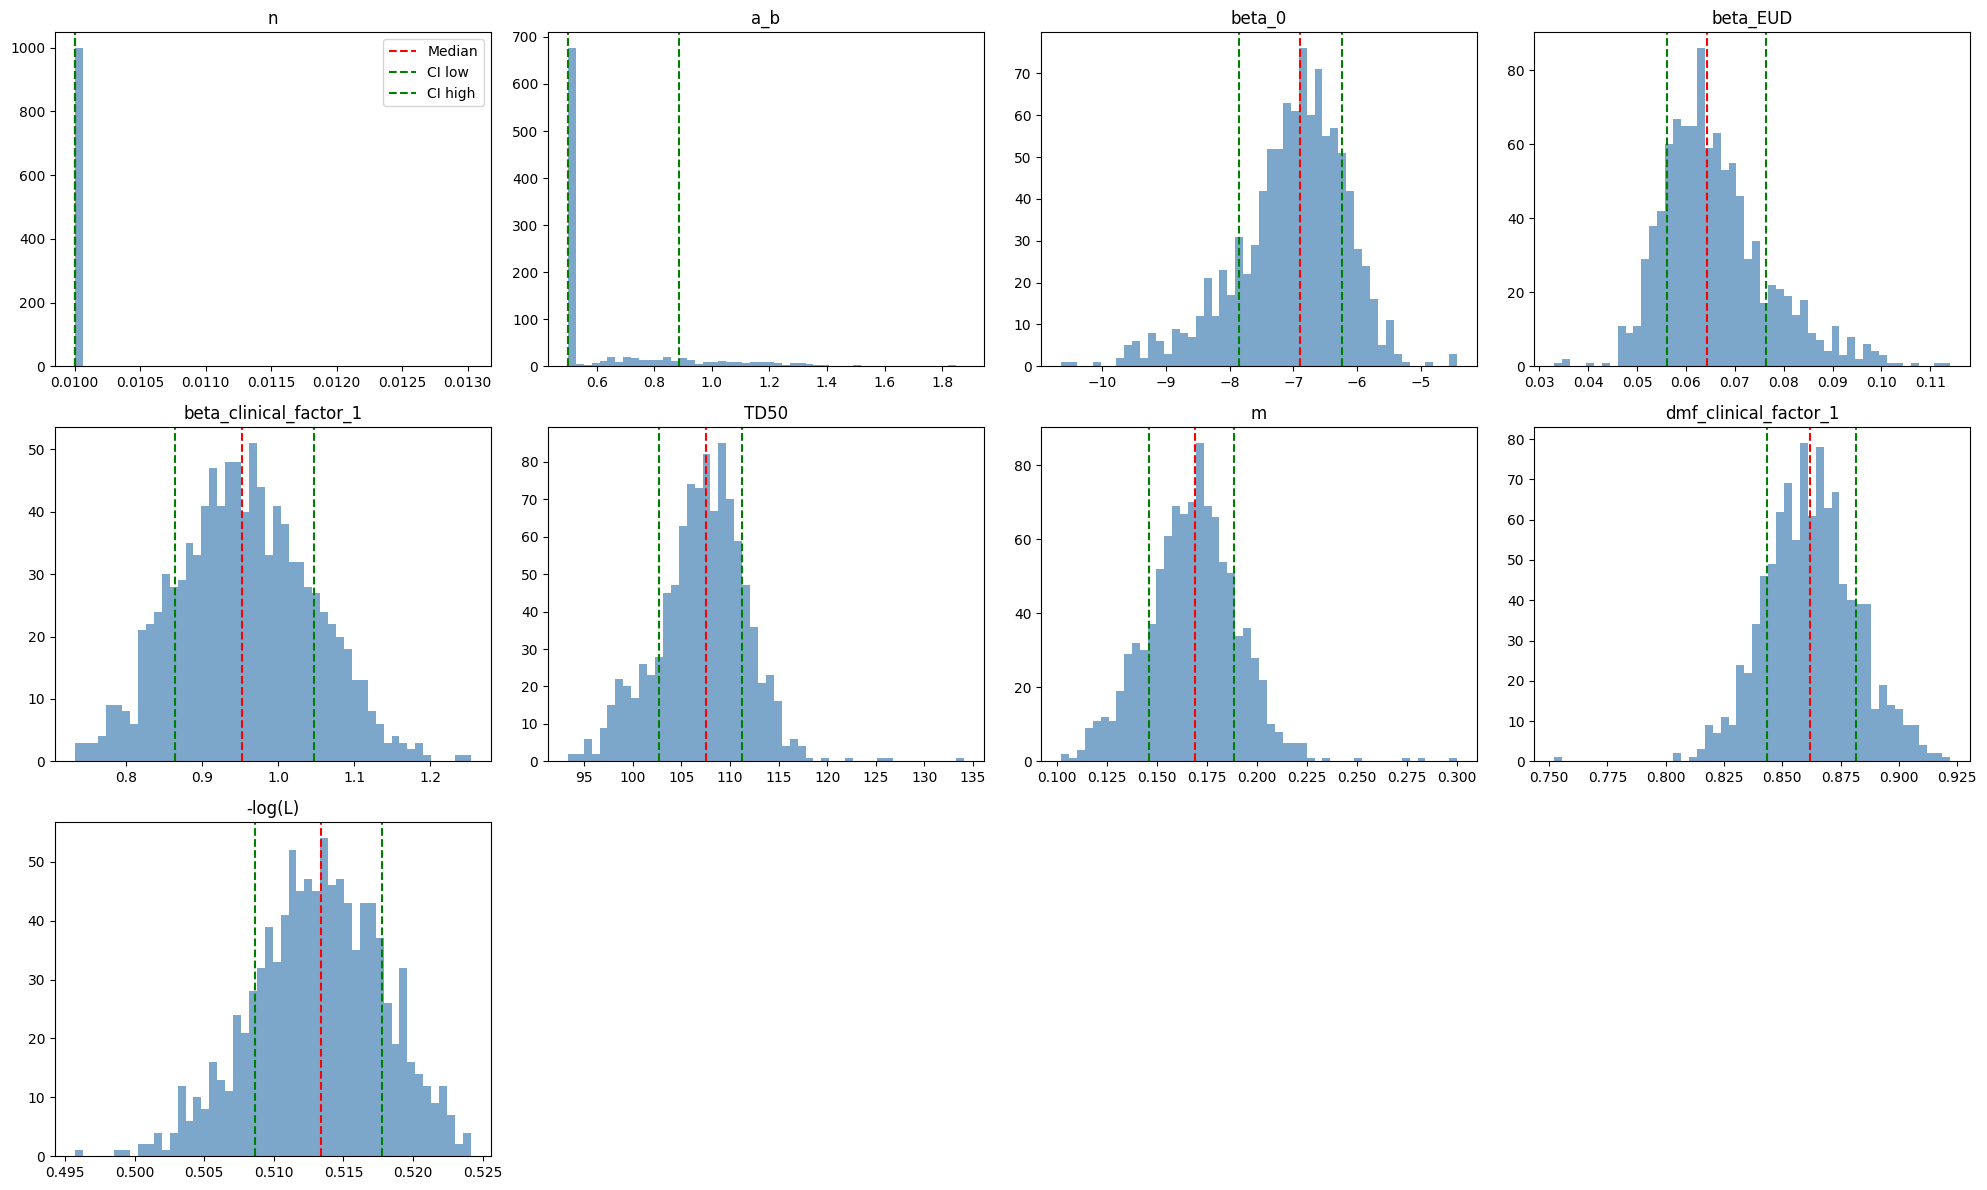

In [28]:
results_summarized, parameters_logistic_model, parameters_lyman_model = summarize_fit(results_jk, coverage = 0.68, plot_histograms = True)
# Summarize jackknife results and visualize final parameter estimates with histograms of the jackknife distributions

In [29]:
print(parameters_logistic_model)
print("")
print(parameters_lyman_model)

      n  a_b    beta_0  beta_EUD  beta_clinical_factor_1
0  0.01  0.5 -6.899651  0.064271                0.952408

      n  a_b        TD50         m  dmf_clinical_factor_1
0  0.01  0.5  107.512639  0.168883               0.861981


In [30]:
res_LRT = likelihood_ratio_test(model_H1=parameters_logistic_model, data=data, model_H0=None)
# Compute the likelihood ratio test against the intercept-only model

Testing 2 parameters: EUD + clinical_factor_1
H0: intercept-only
H1: EUD + clinical_factor_1
NLL(H0)=0.547730, NLL(H1)=0.514953, LR=25.4345, p=0.0000 ***


In [31]:
# Suppose you have the EUD-only model; then you can perform a likelihood ratio test for the TURP factor only
EUD_only_model_parameters = pd.DataFrame([{
    'n': 0.01,
    'a_b': 0.75,
    'beta_0': -6.5,
    'beta_EUD': 0.06
}])
res_LRT_turp = likelihood_ratio_test(model_H1=parameters_logistic_model, data=data, model_H0=EUD_only_model_parameters)

Testing 1 parameter: clinical_factor_1
H0: base_model(EUD)
H1: EUD + clinical_factor_1
NLL(H0)=0.553468, NLL(H1)=0.514953, LR=29.8877, p=4.5781e-08 ***


In [32]:
sim_CI = simultaneous_CI(data, parameters_logistic_model = parameters_logistic_model, fit_parameters = ["n", "a_b", "beta_EUD"], coverage = 0.68)
# Compute the simultaneous confidence intervals for parameters n, a_b and beta_EUD, with global coverage of 68%

sim_CI

,Parameter,Estimate,Low(CI Sim 68%),High(CI Sim 68%)
0,n,0.010000,0.010000,0.058980
1,a_b,0.500000,0.500000,2.459184
2,beta_0,-6.899651,NaN,NaN
3,beta_EUD,0.064271,0.063697,0.070402
4,beta_clinical_factor_1,0.952408,NaN,NaN


# Predictions and model calibration

In [33]:
predictions = predict(data, parameters_logistic_model)
# Compute the predicted probabilities
predictions

=== Classification Metrics ===

Metrics independent of threshold:
AUC (ROC):         0.6637
Average Precision: 0.4076

Metrics using threshold = 0.5:
Accuracy:  0.7655
Precision: 0.5455
Recall:    0.0652
F1 Score:  0.1165

Confusion Matrix using threshold = 0.5:
Predicted → |   0 |   1 |
Actual 0    | 291 |   5 |
Actual 1    |  86 |   6 |


,id,predicted_prob
0,0,0.193234
1,1,0.502638
2,2,0.260979
3,3,0.392859
4,4,0.275293
...,...,...
383,383,0.228090
384,384,0.197350
385,385,0.449023
386,386,0.187196


In [34]:
res_HL = hosmer_lemeshow_test(data['outcome'], predictions['predicted_prob'], g = 10, bins_as_quantiles=False)
# Goodness of fit Hosmer-Lemeshow test

Hosmer-Lemeshow test (g=10, bins selected as uniform):
HL statistic: 6.0525
p-value: 0.6413


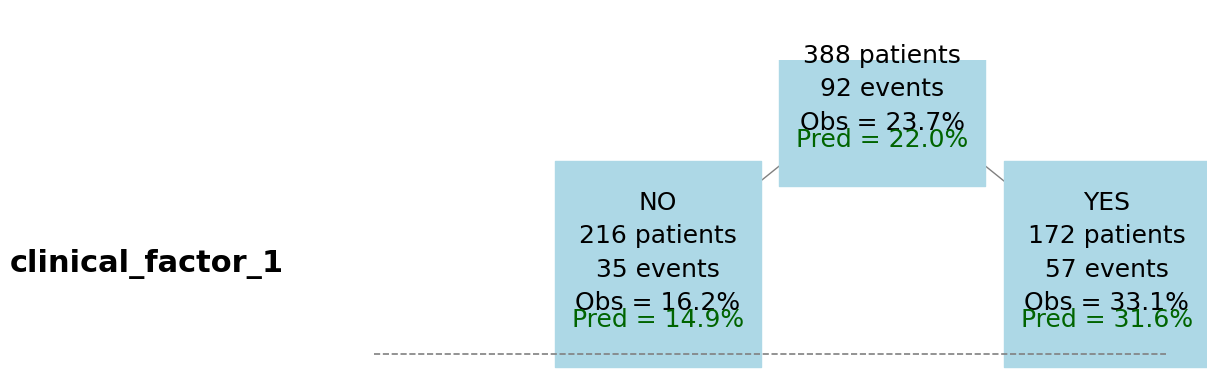

In [44]:
risk_tree(data, parameters_logistic_model)
# Visualize the risk tree

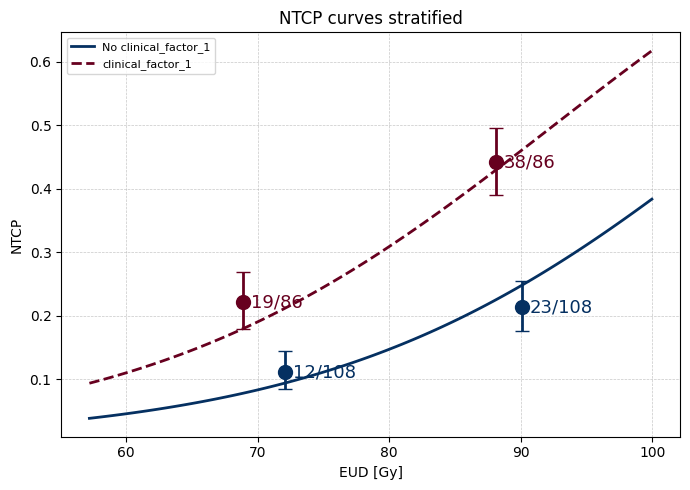

In [36]:
plot_ntcp_stratified(data, parameters_logistic_model, coverage=0.68, min_patients=5, n_quantiles=2)
# Plot the NTCP curves stratifies dy risk factors

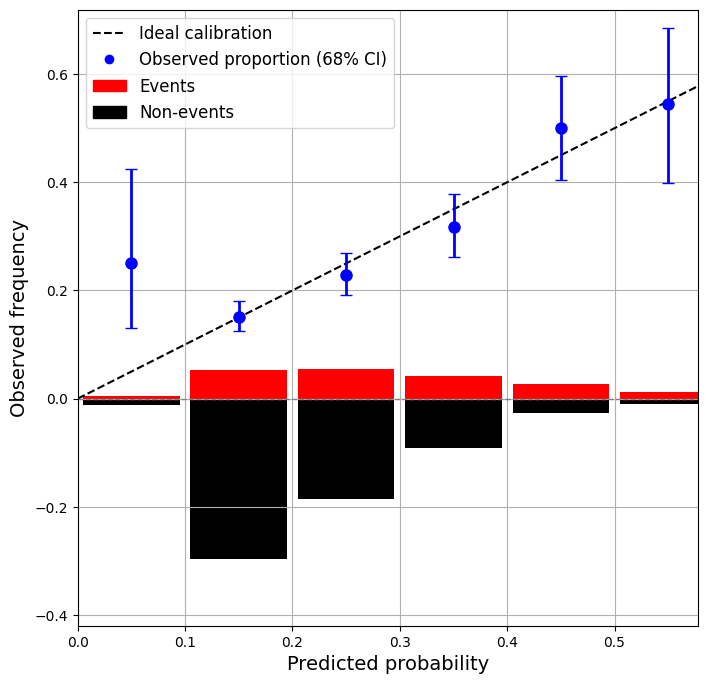

In [37]:
calibration_plot(data, parameters_logistic_model, coverage=0.68, min_pts = 5)
# Plot predicted vs observed probabilities

# Convergence Diagnostic

Locator attempting to generate 1781 ticks ([0.51492, ..., 0.62172]), which exceeds Locator.MAXTICKS (1000).


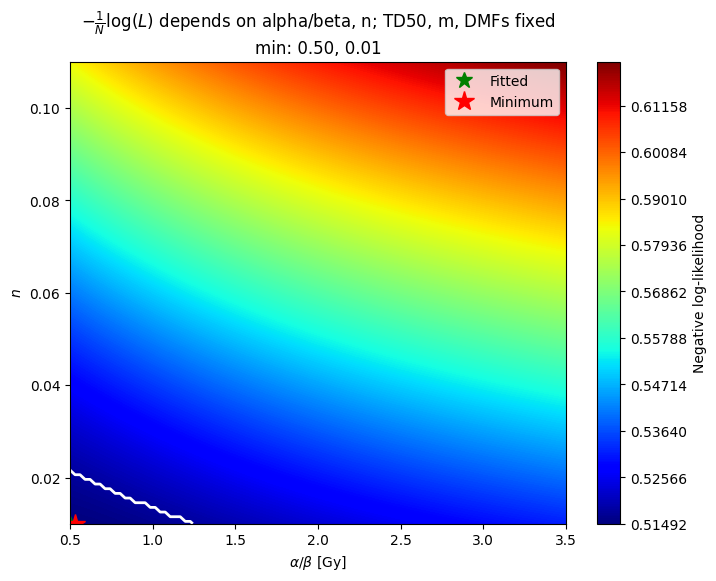

Locator attempting to generate 1655 ticks ([0.5148, ..., 0.8456000000000001]), which exceeds Locator.MAXTICKS (1000).


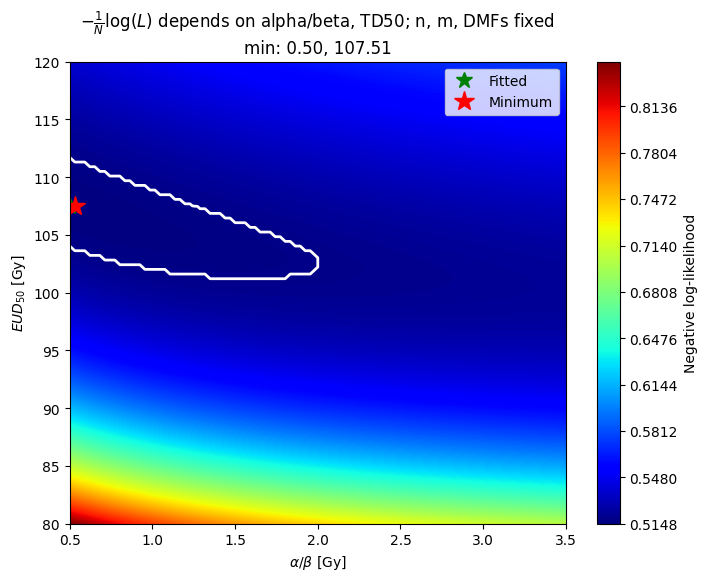

Locator attempting to generate 1655 ticks ([0.5148, ..., 0.8456000000000001]), which exceeds Locator.MAXTICKS (1000).


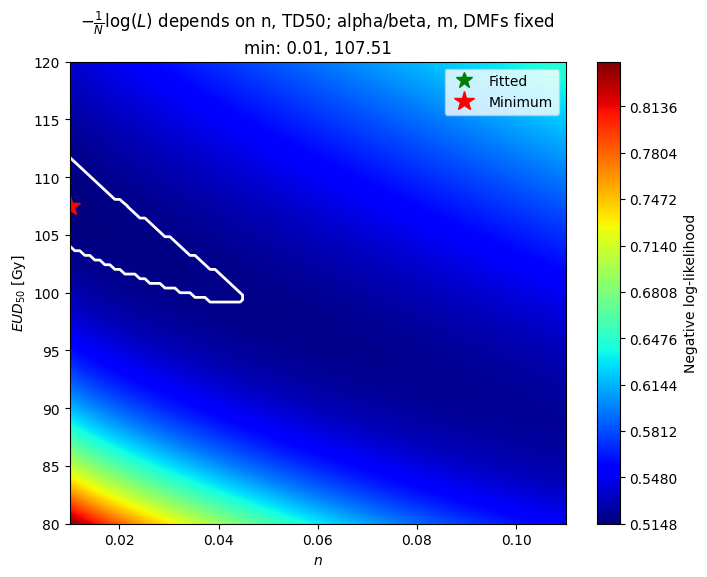

In [38]:
bounds_plot = {"TD50": (80, 120), "n": (0.01, 0.11), "a_b": (0.5, 3.5)}
results_LSP = likelihood_surface_plots(data, parameters_lyman_model, coverage=0.68, bounds=bounds_plot)
# Likelihood plots for TD50, n and a_b parameters (~ 40s on 8 processors)

In [39]:
best, df_refined, df_init, all_results_bf = check_convergence(data)
# Checks optimization robustness by exploring a broad grid and diverse starting points to confirm solution stability

Starting grid search...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed:   13.2s remaining:   19.9s
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:   19.2s remaining:   15.7s
[Parallel(n_jobs=-1)]: Done  14 out of  20 | elapsed:   22.2s remaining:    9.5s
[Parallel(n_jobs=-1)]: Done  17 out of  20 | elapsed:   25.5s remaining:    4.4s
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:   27.2s finished


Grid search completed:
Selected 18 out of 2520000 solutions (0.00 %), using likelihood threshold = 0.52346


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done   7 out of  18 | elapsed:    2.3s remaining:    3.7s
[Parallel(n_jobs=-1)]: Done  11 out of  18 | elapsed:    4.0s remaining:    2.5s
[Parallel(n_jobs=-1)]: Done  15 out of  18 | elapsed:    4.5s remaining:    0.8s
[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:    5.5s finished



n vs alpha/beta:


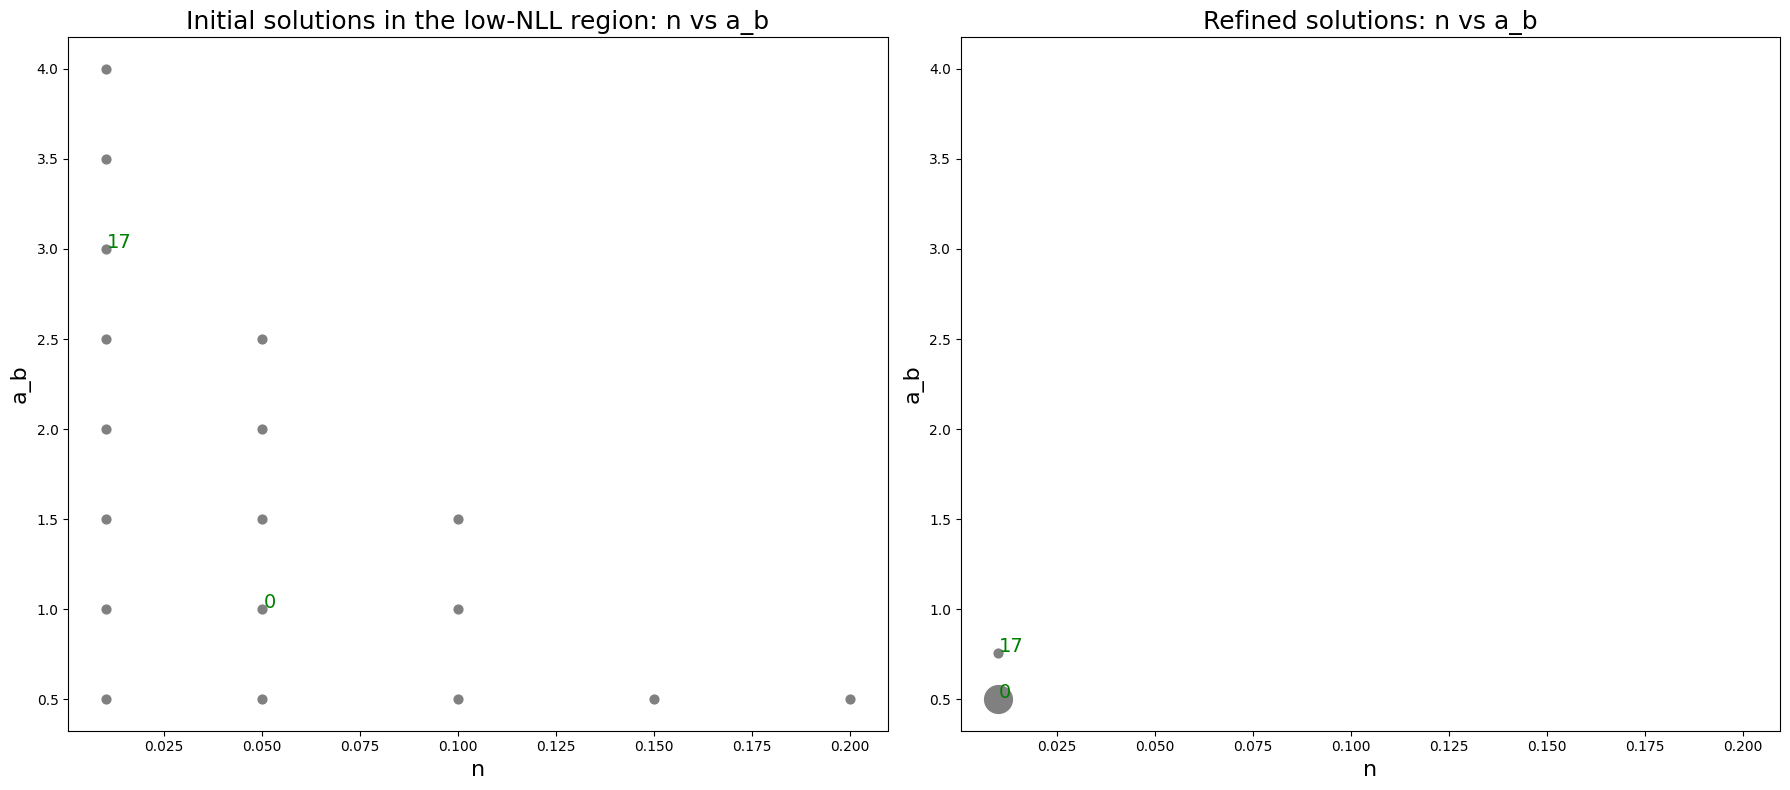

indice     n     a_b   beta_0  beta_EUD  beta_clinical_factor_1  NLL   
-----------------------------------------------------------------------
0, 17 pts  0.01  0.50  -6.73   0.06      0.96                    0.5149
17         0.01  0.76  -6.88   0.06      1.17                    0.5168

n vs beta_0:


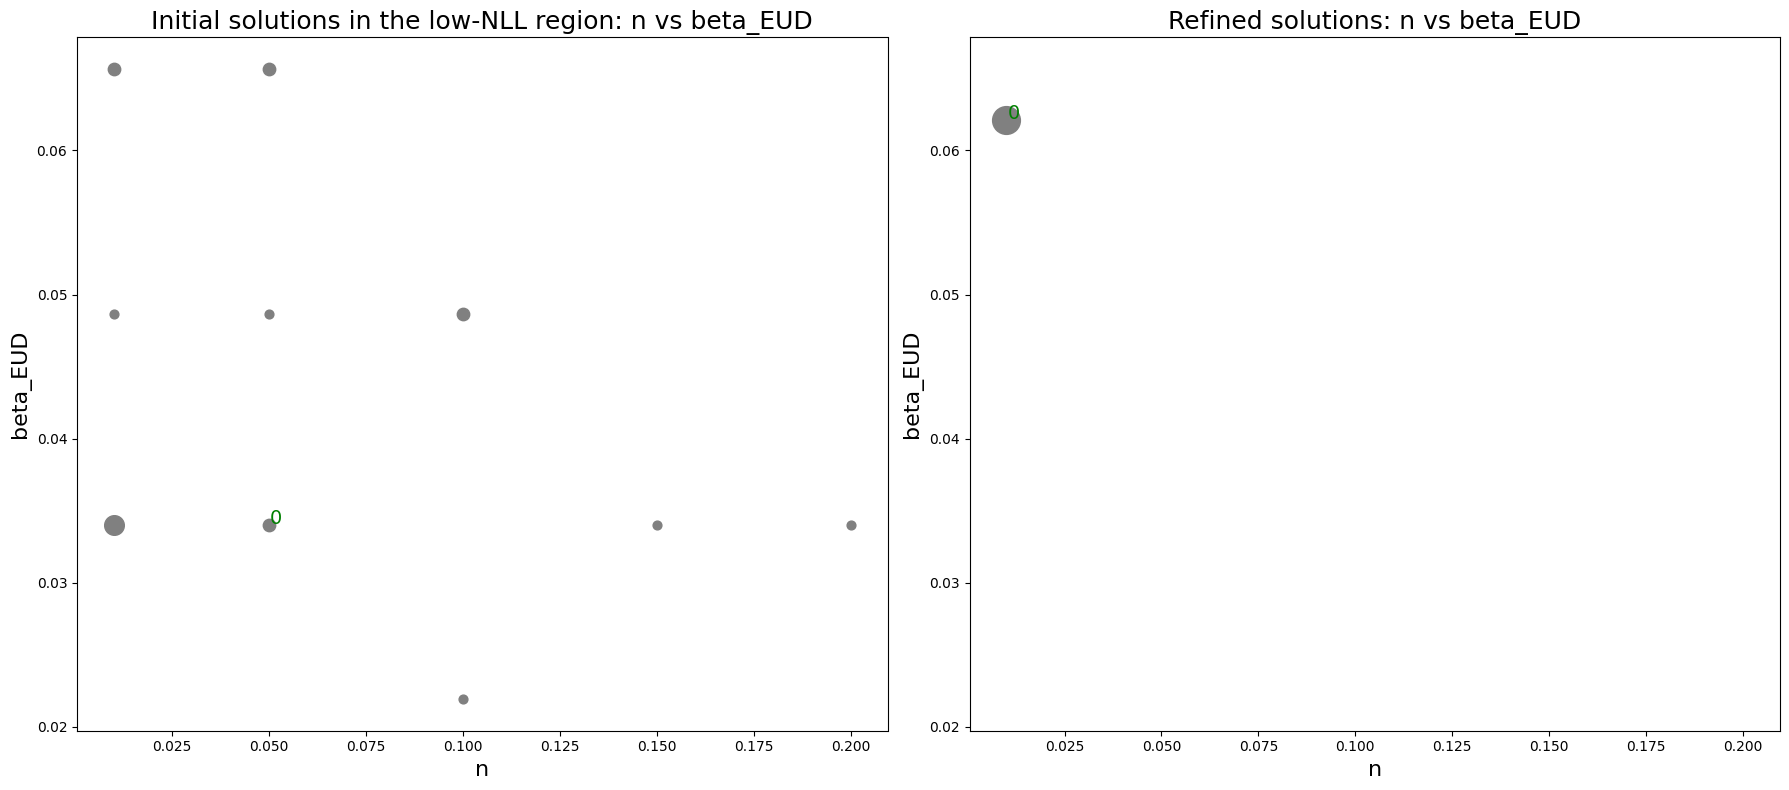

indice     n     a_b   beta_0  beta_EUD  beta_clinical_factor_1  NLL   
-----------------------------------------------------------------------
0, 18 pts  0.01  0.50  -6.73   0.06      0.96                    0.5149

beta_0 vs beta_EUD:


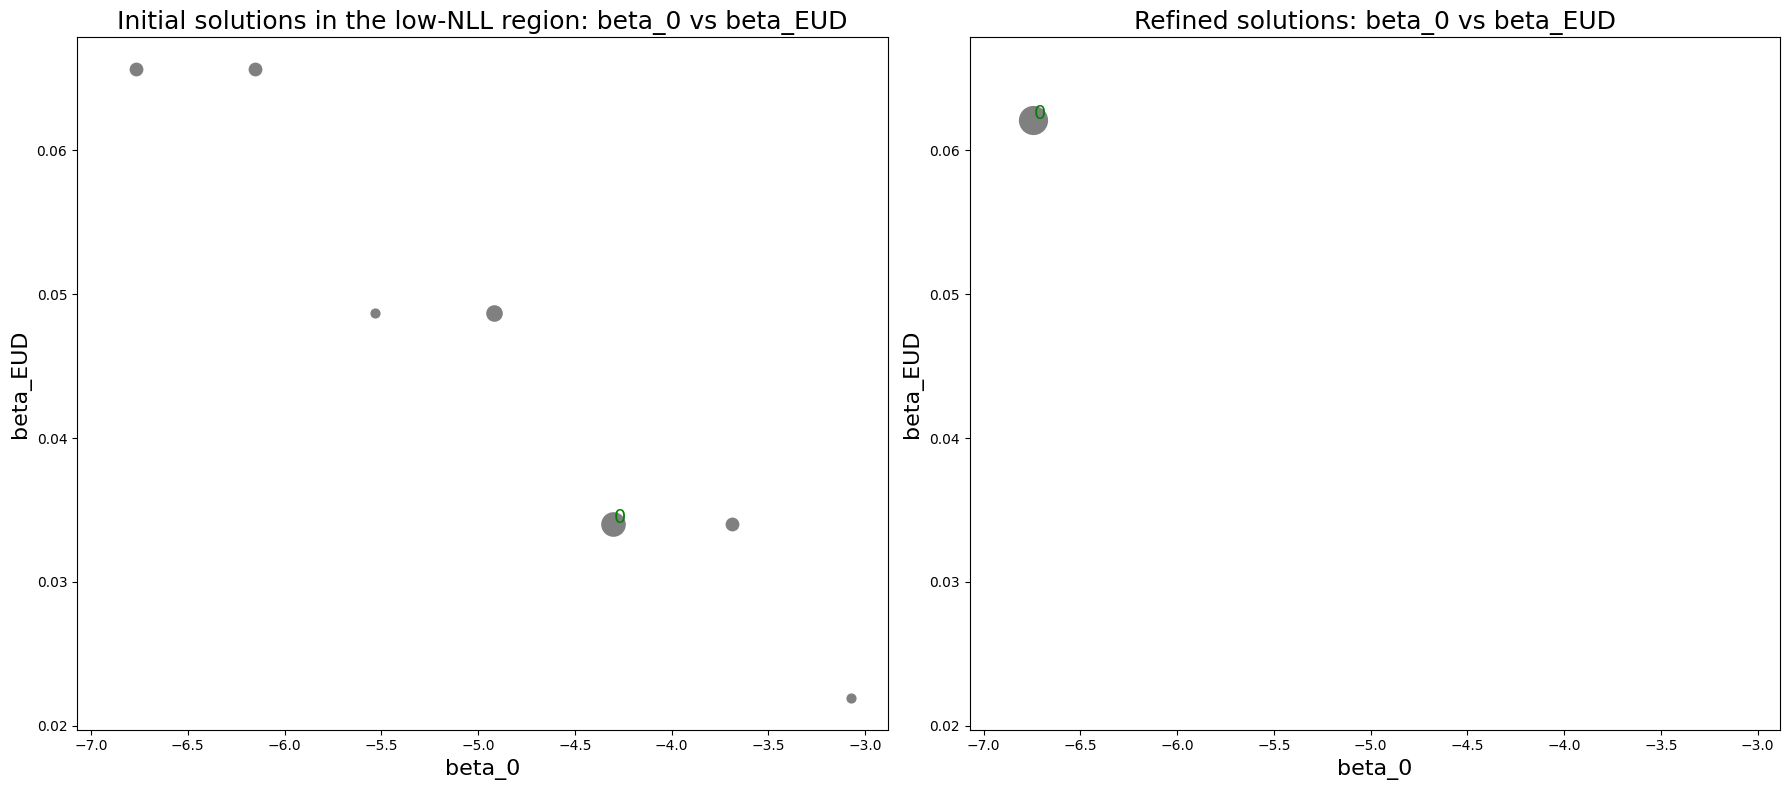

indice     n     a_b   beta_0  beta_EUD  beta_clinical_factor_1  NLL   
-----------------------------------------------------------------------
0, 18 pts  0.01  0.50  -6.73   0.06      0.96                    0.5149

beta_clinical_factor_1 vs beta_EUD:


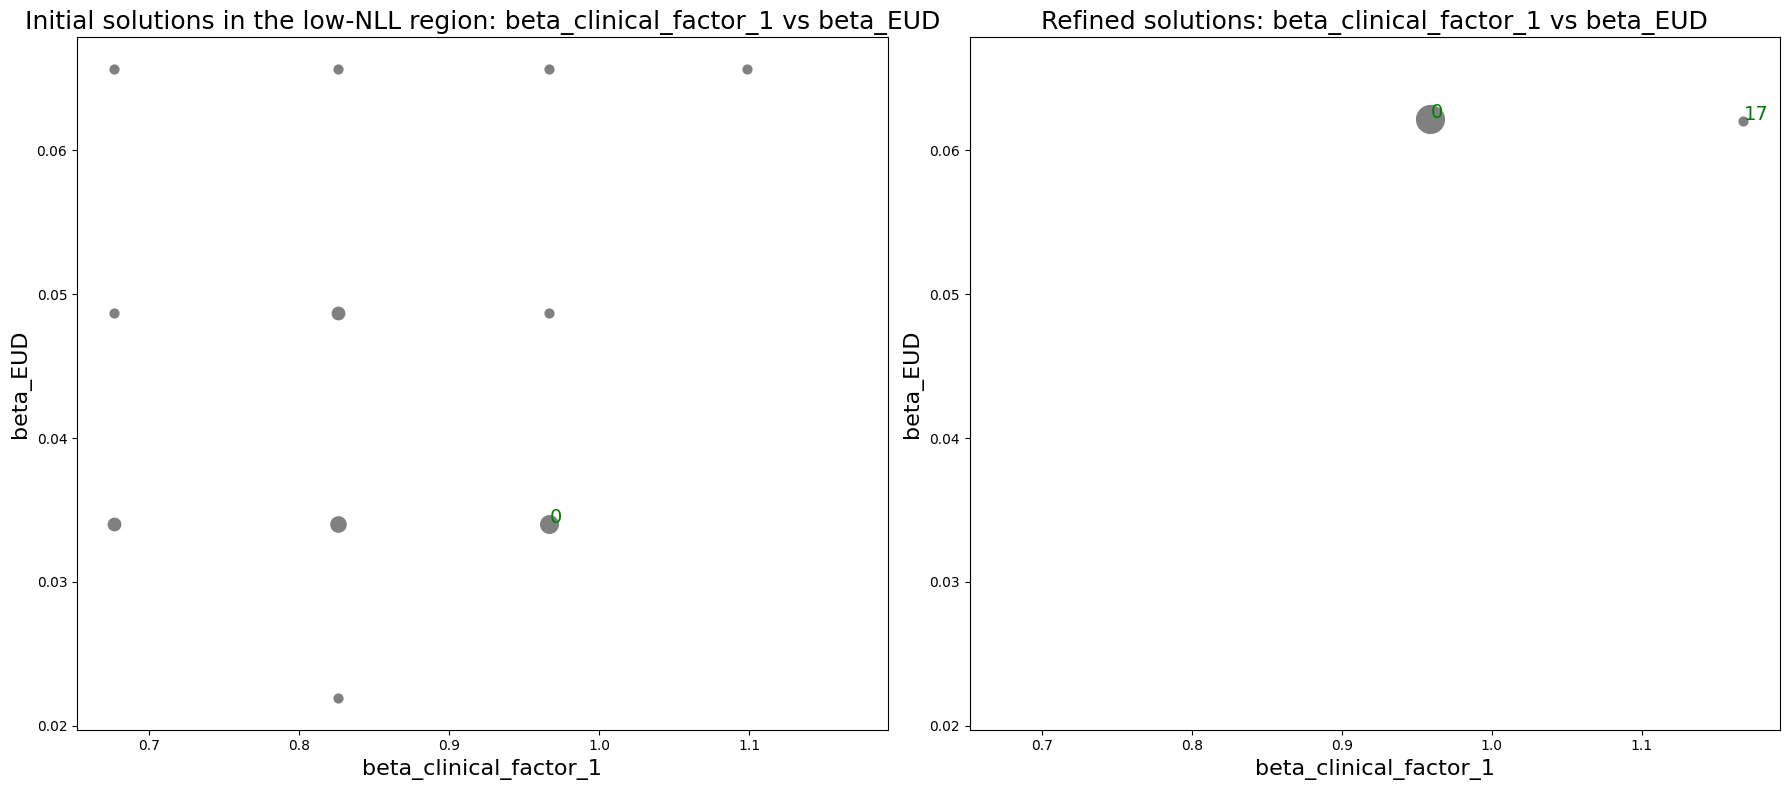

indice     n     a_b   beta_0  beta_EUD  beta_clinical_factor_1  NLL   
-----------------------------------------------------------------------
0, 17 pts  0.01  0.50  -6.73   0.06      0.96                    0.5149
17         0.01  0.76  -6.88   0.06      1.17                    0.5168


In [40]:
print("\nn vs alpha/beta:")
plot_refined_vs_initial(df_init, df_refined, N=len(data['outcome']), x_col="n", y_col="a_b")

print("\nn vs beta_0:")
plot_refined_vs_initial(df_init, df_refined, N=len(data['outcome']), x_col="n", y_col="beta_EUD")

print("\nbeta_0 vs beta_EUD:")
plot_refined_vs_initial(df_init, df_refined, N=len(data['outcome']), x_col="beta_0", y_col="beta_EUD")

print(f"\nbeta_{data['risk_factors'].columns[0]} vs beta_EUD:")
plot_refined_vs_initial(df_init, df_refined, N=len(data['outcome']), x_col=f"beta_{data['risk_factors'].columns[0]}", y_col="beta_EUD")